In [5]:
import pandas as pd
from scipy.optimize import linprog

# Load feature data
feature_importance_df = pd.read_csv('Feature_Importance_by_Sound_Categories.csv')
feature_latency_df = pd.read_csv('Individual_Feature_Extraction_Time_27s.csv')

# Merge utility and latency data
merged_data = feature_latency_df.merge(
    feature_importance_df.set_index('Features').mean(axis=1).reset_index(name='Average Utility'),
    left_on='Feature',
    right_on='Features',
    how='inner'
)

# Define application-specific constraints
latency_constraint = 0.5  # Total latency constraint (e.g., 0.1 seconds)
utility_threshold = 0.05  # Minimum average utility per feature

# Filter out features that do not meet utility threshold
filtered_data = merged_data[merged_data['Average Utility'] >= utility_threshold]

# Define optimization problem inputs
latencies = filtered_data['Time (seconds)'].values
utilities = filtered_data['Average Utility'].values

# Binary decision variables for selecting features (0 or 1)
num_features = len(latencies)

# Objective: Maximize total utility (negative because linprog minimizes)
c = -utilities

# Constraints:
# 1. Total latency <= latency_constraint
A = [latencies]
b = [latency_constraint]

# Bounds: Each feature can be selected (1) or not (0)
bounds = [(0, 1) for _ in range(num_features)]

# Solve using linear programming
result = linprog(c, A_ub=A, b_ub=b, bounds=bounds, method='highs')

# Extract selected features
selected_indices = [i for i, x in enumerate(result.x) if x > 0.5]  # Binary selection
selected_features = filtered_data.iloc[selected_indices]

# Output selected features
selected_features = selected_features[['Feature', 'Time (seconds)', 'Average Utility']]

# # Save the results to a CSV file
# output_path = 'Selected_Optimal_Features.csv'
# selected_features.to_csv(output_path, index=False)
# print(f"Selected optimal features saved to: {output_path}")


In [6]:
selected_features

,Feature,Time (seconds),Average Utility
6,Spectral Rolloff,0.023543,0.05412
8,Spectral Contrast,0.026812,0.06446
9,Chroma Features,0.046643,0.06254
15,Wavelet Features,0.306826,0.05108
16,Timbre,0.055155,0.05900
21,Energy Balance Metric,0.044482,0.05662


In [4]:
merged_data

,Feature,Time (seconds),Features,Average Utility
0,RMS,0.011993,RMS,0.03046
1,ZCR,0.007545,ZCR,0.04040
2,Peak Value,0.000217,Peak Value,0.04202
3,STE,0.000313,STE,0.02670
4,Signal Energy,0.000272,Signal Energy,0.02836
5,Spectral Centroid,0.023160,Spectral Centroid,0.04934
6,Spectral Rolloff,0.023543,Spectral Rolloff,0.05412
7,Spectral Flatness,0.017256,Spectral Flatness,0.03922
8,Spectral Contrast,0.026812,Spectral Contrast,0.06446
9,Chroma Features,0.046643,Chroma Features,0.06254


In [7]:
##import pandas as pd
from scipy.optimize import linprog

def optimize_features(utility_file, latency_file, category, latency_constraint, utility_threshold):
    """
    Select an optimal subset of features based on latency and utility constraints for a specific application category.

    Parameters:
        utility_file (str): Path to the utility CSV file.
        latency_file (str): Path to the latency CSV file.
        category (str): The sound category to optimize for (e.g., 'Human Sounds').
        latency_constraint (float): Maximum allowable latency in seconds.
        utility_threshold (float): Minimum utility value for a feature to be considered.

    Returns:
        pd.DataFrame: DataFrame containing the selected subset of features.
    """
    # Load feature data
    feature_importance_df = pd.read_csv(utility_file)
    feature_latency_df = pd.read_csv(latency_file)

    # Filter utility data for the specific category
    if category not in feature_importance_df.columns:
        raise ValueError(f"Category '{category}' not found in utility file columns.")

    feature_importance_df = feature_importance_df[['Features', category]].rename(columns={category: 'Utility'})

    # Merge utility and latency data
    merged_data = feature_latency_df.merge(
        feature_importance_df,
        left_on='Feature',
        right_on='Features',
        how='inner'
    )

    # Filter out features that do not meet the utility threshold
    filtered_data = merged_data[merged_data['Utility'] >= utility_threshold]

    # Define optimization problem inputs
    latencies = filtered_data['Time (seconds)'].values
    utilities = filtered_data['Utility'].values

    # Binary decision variables for selecting features (0 or 1)
    num_features = len(latencies)

    # Objective: Maximize total utility (negative because linprog minimizes)
    c = -utilities

    # Constraints:
    # 1. Total latency <= latency_constraint
    A = [latencies]
    b = [latency_constraint]

    # Bounds: Each feature can be selected (1) or not (0)
    bounds = [(0, 1) for _ in range(num_features)]

    # Solve using linear programming
    result = linprog(c, A_ub=A, b_ub=b, bounds=bounds, method='highs')

    # Extract selected features
    selected_indices = [i for i, x in enumerate(result.x) if x > 0.5]  # Binary selection
    selected_features = filtered_data.iloc[selected_indices]

    # Return selected features
    return selected_features[['Feature', 'Time (seconds)', 'Utility']]



In [22]:
# Example usage
utility_file = 'Feature_Importance_by_Sound_Categories.csv'
latency_file = 'Individual_Feature_Extraction_Time_27s.csv'
category = 'Human Sounds'
latency_constraint = 0.5  # Total latency constraint (e.g., 0.1 seconds)
utility_threshold = 0.04  # Minimum utility value per feature

selected_features = optimize_features(utility_file, latency_file, category, latency_constraint, utility_threshold)

# # Save the results to a CSV file
# output_path = '/mnt/data/Selected_Optimal_Features.csv'
# selected_features.to_csv(output_path, index=False)
# print(f"Selected optimal features saved to: {output_path}")
selected_features

,Feature,Time (seconds),Utility
2,Peak Value,0.000217,0.0598
5,Spectral Centroid,0.023160,0.0587
6,Spectral Rolloff,0.023543,0.0574
8,Spectral Contrast,0.026812,0.0640
9,Chroma Features,0.046643,0.0533
15,Wavelet Features,0.306826,0.0541
16,Timbre,0.055155,0.0805
21,Energy Balance Metric,0.044482,0.0675


In [23]:
selected_features2 = optimize_features(utility_file, latency_file, 'Interior Sounds', latency_constraint, utility_threshold)
selected_features2

,Feature,Time (seconds),Utility
1,ZCR,0.007545,0.0414
2,Peak Value,0.000217,0.0472
5,Spectral Centroid,0.023160,0.0576
6,Spectral Rolloff,0.023543,0.0576
7,Spectral Flatness,0.017256,0.0421
8,Spectral Contrast,0.026812,0.0590
9,Chroma Features,0.046643,0.0437
10,Pitch,0.025658,0.0432
15,Wavelet Features,0.306826,0.0635
16,Timbre,0.055155,0.0677


In [30]:
import pandas as pd

# Feature names
features = [
    'RMS', 'ZCR', 'Peak Value', 'STE', 'Signal Energy', 'Spectral Centroid',
    'Spectral Rolloff', 'Spectral Flatness', 'Spectral Contrast',
    'Chroma Features', 'Pitch', 'HNR', 'Harmonic Ratio', 'Spectral Flux',
    'Group Delay', 'Wavelet Features', 'Timbre', 'Loudness', 'Jitter',
    'Shimmer', 'Bark Coefficients', 'Mel-Spectra', 'Zwicker Loudness',
    'Energy Balance Metric', 'LH1000', 'SNR', 'Window Index'
]

# Privacy leakage values for each category
age_leakage = [
    0.02648242, 0.04573161, 0.04545913, 0.028491, 0.03239771, 0.036904,
    0.04499533, 0.03705103, 0.05040014, 0.0416738, 0.041871, 0.03536881,
    0.03578275, 0.04839586, 0.03062226, 0.03698573, 0.04110304, 0.0285842,
    0.03805888, 0.03029296, 0.0318757, 0.03391937, 0.02645845, 0.03800537,
    0.03547184, 0.03468198, 0.04293562
]

gender_leakage = [
    0.02557201, 0.02368976, 0.04209529, 0.03553794, 0.03040282, 0.0285932,
    0.02727099, 0.03487246, 0.07547168, 0.12672592, 0.03093066, 0.0281987,
    0.02671795, 0.03557703, 0.03095203, 0.052716, 0.07227312, 0.0254977,
    0.03276125, 0.02764549, 0.02586145, 0.02837278, 0.02746414, 0.02843916,
    0.02692922, 0.02839857, 0.0210327
]

ethinicity_leakage = [
    0.02992865, 0.04357937, 0.05122175, 0.02793845, 0.0291442, 0.03747142,
    0.02940428, 0.04156199, 0.03187886, 0.03339192, 0.05517321, 0.04014784,
    0.0422415, 0.03360867, 0.0364098, 0.05321831, 0.04699539, 0.0308183,
    0.03302018, 0.02691717, 0.04078311, 0.03307419, 0.02772869, 0.03864537,
    0.03033783, 0.04273531, 0.03262427
]

# Create DataFrame
privacy_leakage_df = pd.DataFrame({
    'Feature': features,
    'Age Leakage': age_leakage,
    'Gender Leakage': gender_leakage,
    'Ethnicity Leakage': ethinicity_leakage
})

# Save the DataFrame to a CSV file
output_path = 'Privacy_Leakage_Data.csv'
privacy_leakage_df.to_csv(output_path, index=False)

print(f"Privacy Leakage Data saved to {output_path}")


Privacy Leakage Data saved to Privacy_Leakage_Data.csv


In [28]:
len(features), len(ethinicity_leakage)

(27, 27)

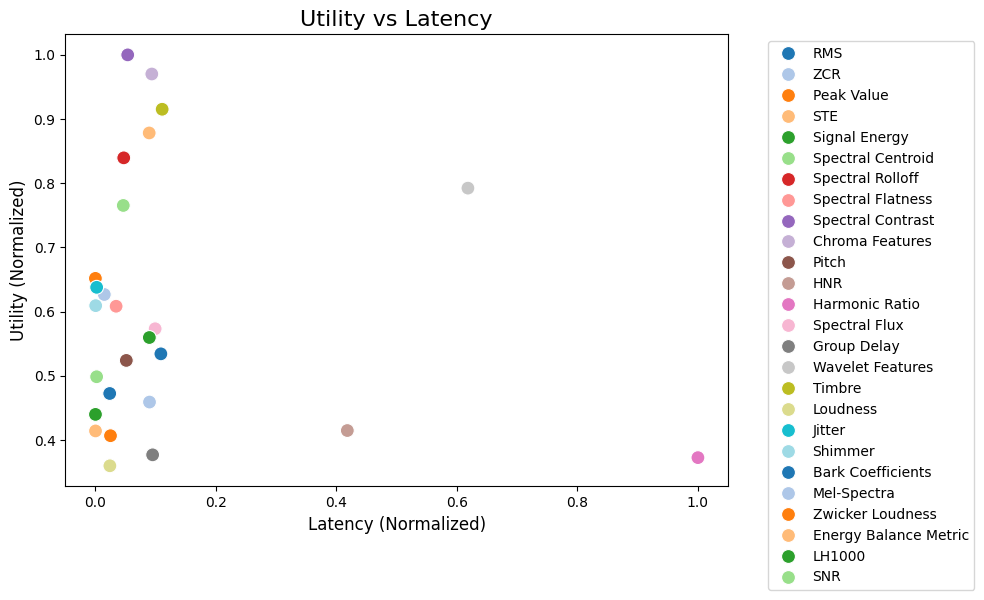

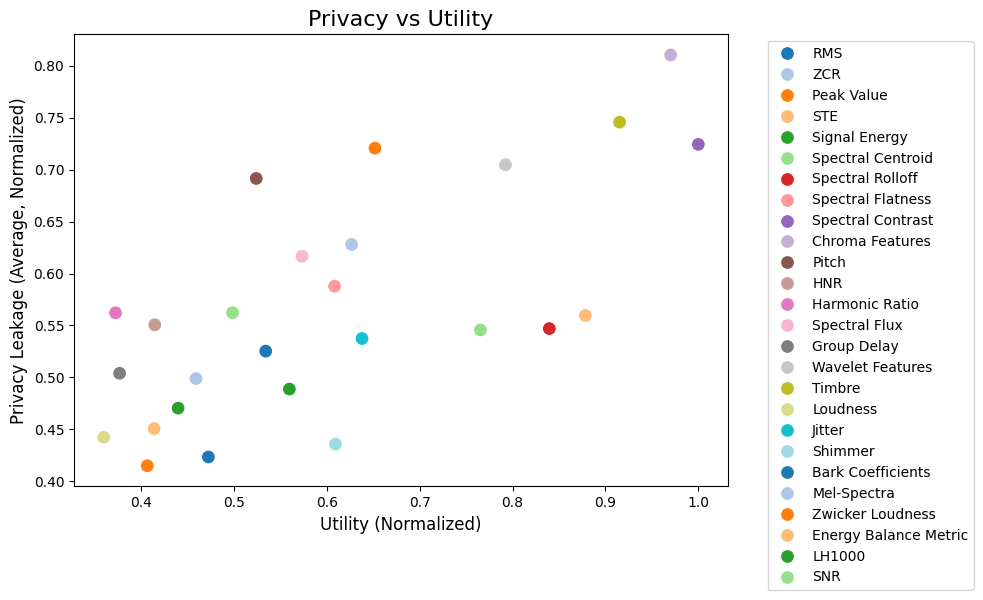

TypeError: Could not convert ['RMSZCRPeak ValueSTESignal Energy' 'RMSZCRPeak ValueSTESignal Energy'] to numeric

In [43]:
#Visualizations



import pandas as pd

# Load the uploaded files
privacy_file_path = 'Privacy_Leakage_Data.csv'
utility_file_path = 'Feature_Importance_by_Sound_Categories.csv'
latency_file_path = 'Individual_Feature_Extraction_Time_27s.csv'

# Read data into DataFrames
privacy_leakage_df = pd.read_csv(privacy_file_path)
feature_importance_df = pd.read_csv(utility_file_path)
latency_df = pd.read_csv(latency_file_path)

# Display the first few rows of each DataFrame to understand their structure
privacy_leakage_df.head(), feature_importance_df.head(), latency_df.head()


import matplotlib.pyplot as plt
import seaborn as sns

# Merge all data into one DataFrame
merged_data = latency_df.merge(
    feature_importance_df.set_index('Features').mean(axis=1).reset_index(name='Average Utility'),
    left_on='Feature',
    right_on='Features',
    how='inner'
).merge(
    privacy_leakage_df,
    on='Feature',
    how='inner'
)

# Normalize data for consistent comparison
merged_data['Age Leakage'] /= merged_data['Age Leakage'].max()
merged_data['Gender Leakage'] /= merged_data['Gender Leakage'].max()
merged_data['Ethnicity Leakage'] /= merged_data['Ethnicity Leakage'].max()
merged_data['Time (seconds)'] /= merged_data['Time (seconds)'].max()
merged_data['Average Utility'] /= merged_data['Average Utility'].max()

# Visualizations: Tradeoffs

# 1. Utility vs Latency
plt.figure(figsize=(10, 6))
sns.scatterplot(data=merged_data, x='Time (seconds)', y='Average Utility', hue='Feature', s=100, palette='tab20')
plt.title('Utility vs Latency', fontsize=16)
plt.xlabel('Latency (Normalized)', fontsize=12)
plt.ylabel('Utility (Normalized)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 2. Privacy vs Utility (Aggregated)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=merged_data,
    x='Average Utility',
    y=merged_data[['Age Leakage', 'Gender Leakage', 'Ethnicity Leakage']].mean(axis=1),
    hue='Feature',
    s=100,
    palette='tab20'
)
plt.title('Privacy vs Utility', fontsize=16)
plt.xlabel('Utility (Normalized)', fontsize=12)
plt.ylabel('Privacy Leakage (Average, Normalized)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Step B: Groupwise Aggregation
feature_groups = {
    'Time Domain Analysis': ['RMS', 'ZCR', 'Peak Value', 'STE', 'Signal Energy'],
    'Spectral Features': ['Spectral Centroid', 'Spectral Rolloff', 'Spectral Flatness', 'Spectral Contrast', 'Chroma Features'],
    'Harmonic Features': ['Pitch', 'HNR', 'Harmonic Ratio'],
    'Time-Frequency Features': ['Spectral Flux', 'Group Delay', 'Wavelet Features'],
    'Perceptual Features': ['Timbre', 'Loudness', 'Jitter', 'Shimmer'],
    'Psychoacoustic Features': ['Bark Coefficients', 'Mel-Spectra', 'Zwicker Loudness'],
    'Derived Features': ['Energy Balance Metric', 'LH1000', 'SNR']
}

grouped_data = []

# Aggregate data by group
for group, features in feature_groups.items():
    group_data = merged_data[merged_data['Feature'].isin(features)].mean()
    grouped_data.append({'Group': group, **group_data})

grouped_df = pd.DataFrame(grouped_data)

# Visualize Groupwise Aggregated Data
plt.figure(figsize=(10, 6))
sns.barplot(data=grouped_df, x='Group', y='Average Utility', palette='viridis')
plt.title('Average Utility by Feature Group', fontsize=16)
plt.xlabel('Feature Group', fontsize=12)
plt.ylabel('Utility (Normalized)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(data=grouped_df, x='Group', y='Time (seconds)', palette='coolwarm')
plt.title('Average Latency by Feature Group', fontsize=16)
plt.xlabel('Feature Group', fontsize=12)
plt.ylabel('Latency (Normalized)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(data=grouped_df, x='Group', y=grouped_df[['Age Leakage', 'Gender Leakage', 'Ethnicity Leakage']].mean(axis=1), palette='magma')
plt.title('Average Privacy Leakage by Feature Group', fontsize=16)
plt.xlabel('Feature Group', fontsize=12)
plt.ylabel('Privacy Leakage (Normalized)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [45]:
merged_data

,Feature,Time (seconds),Features,Average Utility,Age Leakage,Gender Leakage,Ethnicity Leakage
0,RMS,0.024173,RMS,0.472541,0.525443,0.201790,0.542449
1,ZCR,0.015209,ZCR,0.626745,0.907371,0.186937,0.789865
2,Peak Value,0.000438,Peak Value,0.651877,0.901964,0.332176,0.928381
3,STE,0.000630,STE,0.414210,0.565296,0.280432,0.506377
4,Signal Energy,0.000547,Signal Energy,0.439963,0.642810,0.239910,0.528231
5,Spectral Centroid,0.046681,Spectral Centroid,0.765436,0.732220,0.225630,0.679160
6,Spectral Rolloff,0.047453,Spectral Rolloff,0.839590,0.892762,0.215197,0.532945
7,Spectral Flatness,0.034781,Spectral Flatness,0.608439,0.735137,0.275180,0.753300
8,Spectral Contrast,0.054043,Spectral Contrast,1.000000,1.000000,0.595550,0.577796
9,Chroma Features,0.094015,Chroma Features,0.970214,0.826859,1.000000,0.605220


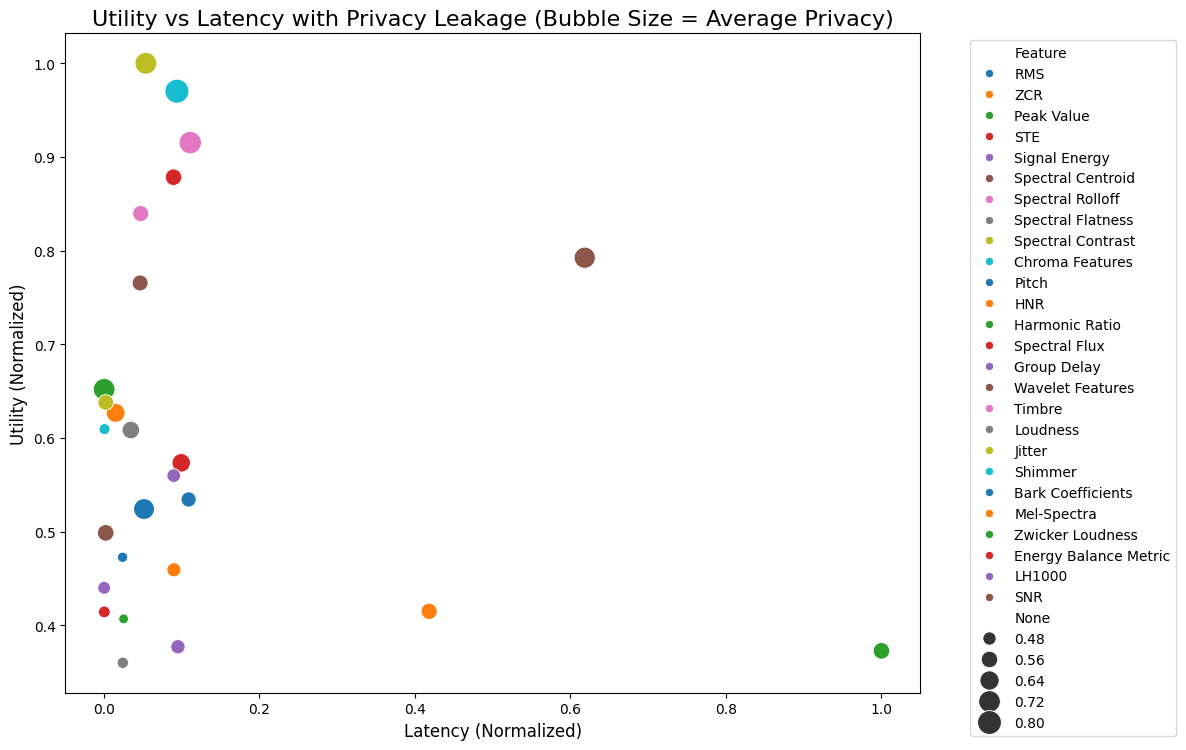

<Figure size 1400x800 with 0 Axes>

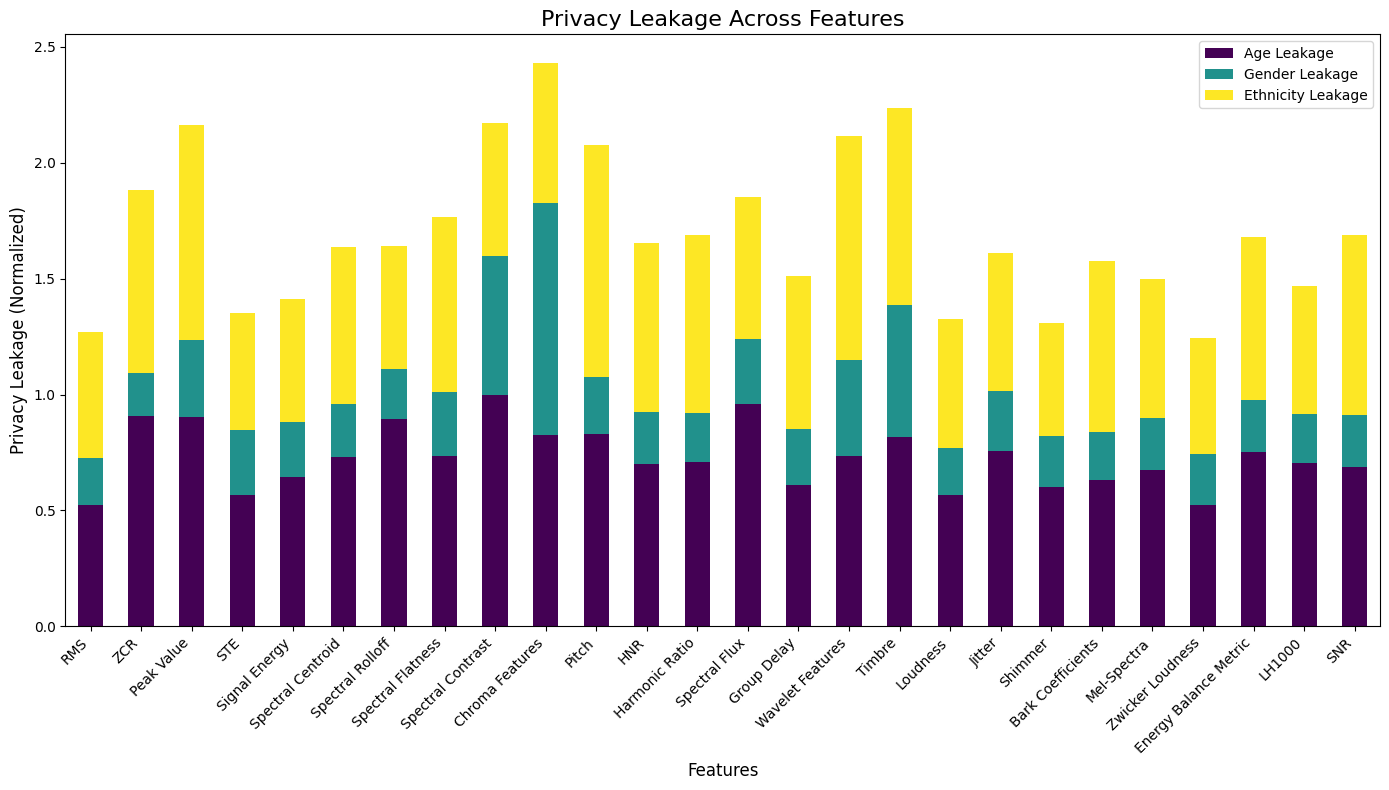

TypeError: Could not convert ['RMSZCRPeak ValueSTESignal Energy' 'RMSZCRPeak ValueSTESignal Energy'] to numeric

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# Merge all data into one DataFrame
merged_data = latency_df.merge(
    feature_importance_df.set_index('Features').mean(axis=1).reset_index(name='Average Utility'),
    left_on='Feature',
    right_on='Features',
    how='inner'
).merge(
    privacy_leakage_df,
    on='Feature',
    how='inner'
)

# Normalize data for better comparison
merged_data['Time (seconds)'] /= merged_data['Time (seconds)'].max()
merged_data['Average Utility'] /= merged_data['Average Utility'].max()
merged_data['Age Leakage'] /= merged_data['Age Leakage'].max()
merged_data['Gender Leakage'] /= merged_data['Gender Leakage'].max()
merged_data['Ethnicity Leakage'] /= merged_data['Ethnicity Leakage'].max()

# 1. Utility vs Latency with Privacy Leakage (Scatter Plot)
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=merged_data,
    x='Time (seconds)',
    y='Average Utility',
    size=merged_data[['Age Leakage', 'Gender Leakage', 'Ethnicity Leakage']].mean(axis=1),
    hue='Feature',
    sizes=(50, 300),
    palette='tab10'
)
plt.title('Utility vs Latency with Privacy Leakage (Bubble Size = Average Privacy)', fontsize=16)
plt.xlabel('Latency (Normalized)', fontsize=12)
plt.ylabel('Utility (Normalized)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 2. Privacy Leakage Across Features (Bar Plot)
plt.figure(figsize=(14, 8))
privacy_data = merged_data[['Feature', 'Age Leakage', 'Gender Leakage', 'Ethnicity Leakage']].set_index('Feature')
privacy_data.plot(kind='bar', stacked=True, colormap='viridis', figsize=(14, 8))
plt.title('Privacy Leakage Across Features', fontsize=16)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Privacy Leakage (Normalized)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Feature Groups
feature_groups = {
    'Time Domain Analysis': ['RMS', 'ZCR', 'Peak Value', 'STE', 'Signal Energy'],
    'Spectral Features': ['Spectral Centroid', 'Spectral Rolloff', 'Spectral Flatness', 'Spectral Contrast', 'Chroma Features'],
    'Harmonic Features': ['Pitch', 'HNR', 'Harmonic Ratio'],
    'Time-Frequency Features': ['Spectral Flux', 'Group Delay', 'Wavelet Features'],
    'Perceptual Features': ['Timbre', 'Loudness', 'Jitter', 'Shimmer'],
    'Psychoacoustic Features': ['Bark Coefficients', 'Mel-Spectra', 'Zwicker Loudness'],
    'Derived Features': ['Energy Balance Metric', 'LH1000', 'SNR']
}

grouped_data = []

# Aggregate data for groups
for group, features in feature_groups.items():
    group_data = merged_data[merged_data['Feature'].isin(features)].mean()
    grouped_data.append({'Group': group, **group_data})

grouped_df = pd.DataFrame(grouped_data)

# 3. Groupwise Utility, Latency, and Privacy Leakage
plt.figure(figsize=(12, 8))
sns.barplot(data=grouped_df, x='Group', y='Average Utility', palette='viridis')
plt.title('Average Utility by Feature Group', fontsize=16)
plt.xlabel('Feature Group', fontsize=12)
plt.ylabel('Utility (Normalized)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
sns.barplot(data=grouped_df, x='Group', y='Time (seconds)', palette='coolwarm')
plt.title('Average Latency by Feature Group', fontsize=16)
plt.xlabel('Feature Group', fontsize=12)
plt.ylabel('Latency (Normalized)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
sns.barplot(data=grouped_df, x='Group', y=grouped_df[['Age Leakage', 'Gender Leakage', 'Ethnicity Leakage']].mean(axis=1), palette='magma')
plt.title('Average Privacy Leakage by Feature Group', fontsize=16)
plt.xlabel('Feature Group', fontsize=12)
plt.ylabel('Privacy Leakage (Normalized)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


/var/folders/qf/r_bx8wf14lx6m_jgptyp_vmr0000gq/T/ipykernel_90491/1738340424.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=grouped_df, x='Group', y='Average Utility', palette='viridis')


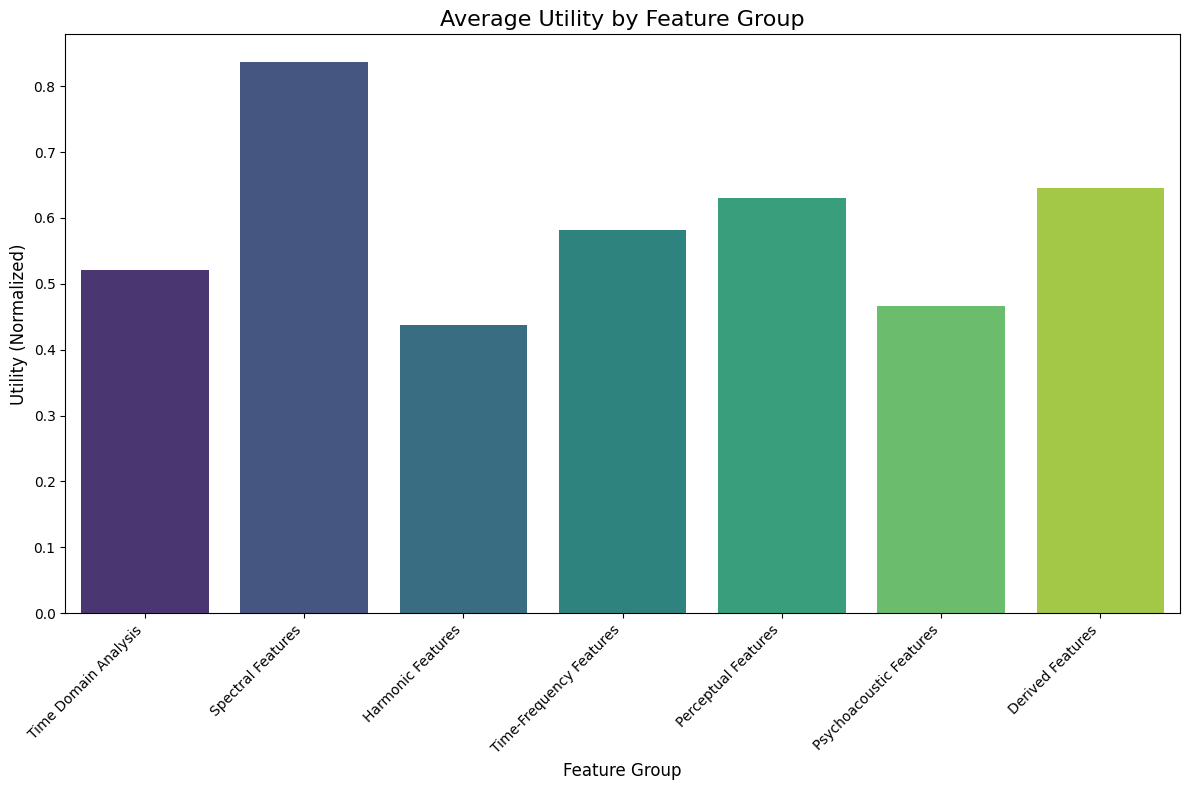

/var/folders/qf/r_bx8wf14lx6m_jgptyp_vmr0000gq/T/ipykernel_90491/1738340424.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=grouped_df, x='Group', y='Time (seconds)', palette='coolwarm')


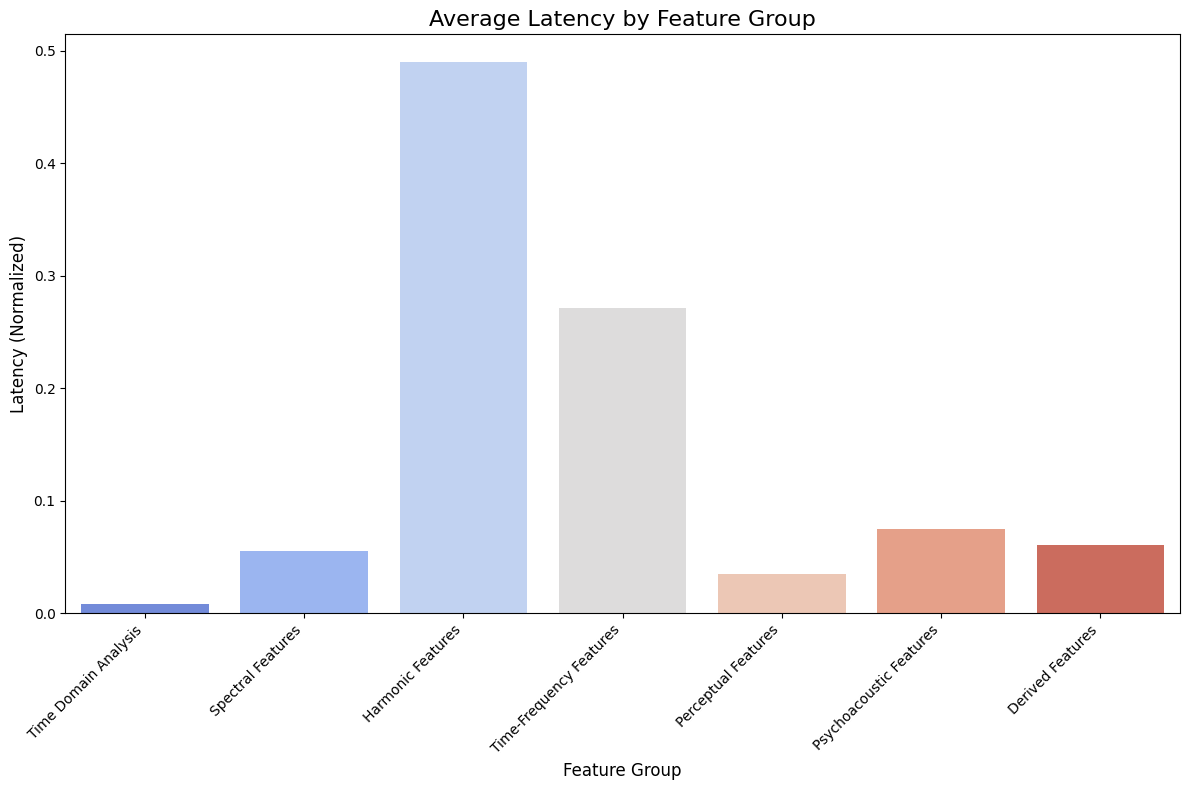

/var/folders/qf/r_bx8wf14lx6m_jgptyp_vmr0000gq/T/ipykernel_90491/1738340424.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=grouped_df, x='Group', y=grouped_df[['Age Leakage', 'Gender Leakage', 'Ethnicity Leakage']].mean(axis=1), palette='magma')


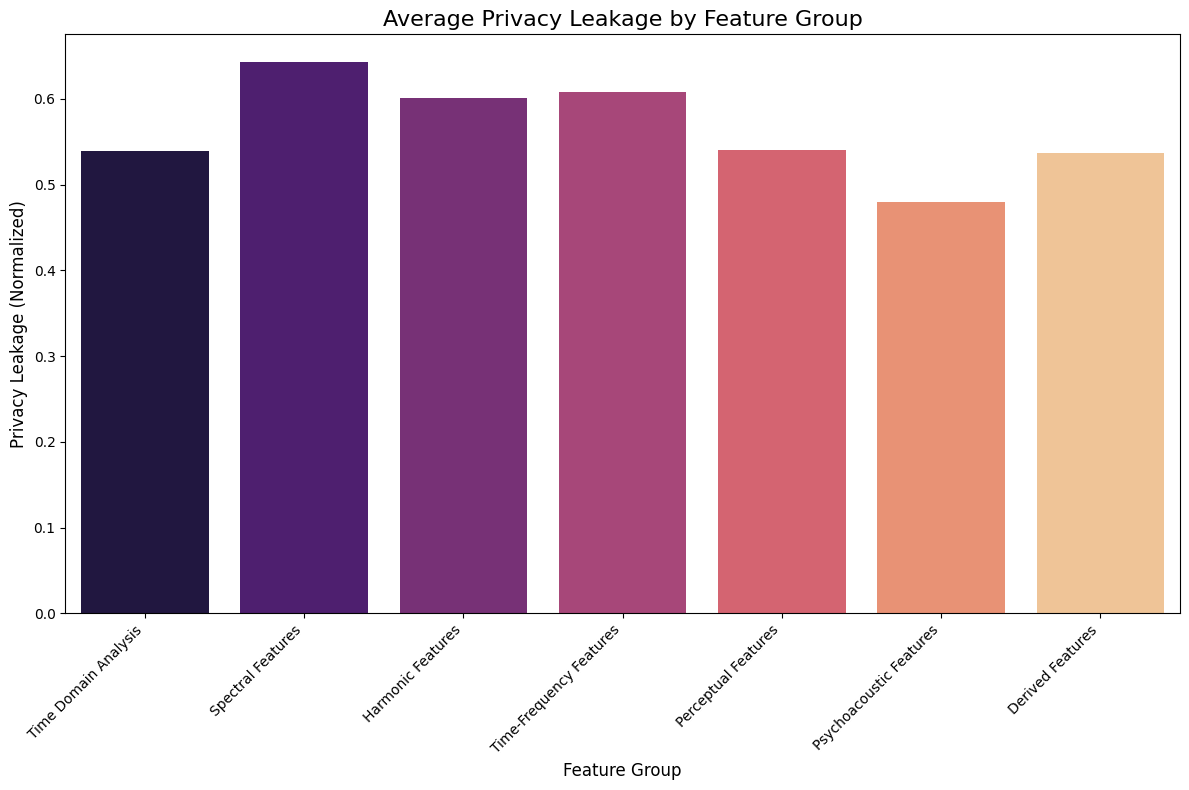

In [73]:
# # Reload the uploaded files for groupwise visualizations
# latency_file_path = '/mnt/data/Individual_Feature_Extraction_Time_27s.csv'
# privacy_file_path = '/mnt/data/Privacy_Leakage_Data.csv'
# utility_file_path = '/mnt/data/Feature_Importance_by_Sound_Categories.csv'

# # Read data into DataFrames
# latency_df = pd.read_csv(latency_file_path)
# privacy_leakage_df = pd.read_csv(privacy_file_path)
# feature_importance_df = pd.read_csv(utility_file_path)

# Merge the data into one comprehensive DataFrame
merged_data = latency_df.merge(
    feature_importance_df.set_index('Features').mean(axis=1).reset_index(name='Average Utility'),
    left_on='Feature',
    right_on='Features',
    how='inner'
).merge(
    privacy_leakage_df,
    on='Feature',
    how='inner'
)

# Normalize data for consistency
merged_data['Time (seconds)'] /= merged_data['Time (seconds)'].max()
merged_data['Average Utility'] /= merged_data['Average Utility'].max()
merged_data['Age Leakage'] /= merged_data['Age Leakage'].max()
merged_data['Gender Leakage'] /= merged_data['Gender Leakage'].max()
merged_data['Ethnicity Leakage'] /= merged_data['Ethnicity Leakage'].max()

# Define Feature Groups
feature_groups = {
    'Time Domain Analysis': ['RMS', 'ZCR', 'Peak Value', 'STE', 'Signal Energy'],
    'Spectral Features': ['Spectral Centroid', 'Spectral Rolloff', 'Spectral Flatness', 'Spectral Contrast', 'Chroma Features'],
    'Harmonic Features': ['Pitch', 'HNR', 'Harmonic Ratio'],
    'Time-Frequency Features': ['Spectral Flux', 'Group Delay', 'Wavelet Features'],
    'Perceptual Features': ['Timbre', 'Loudness', 'Jitter', 'Shimmer'],
    'Psychoacoustic Features': ['Bark Coefficients', 'Mel-Spectra', 'Zwicker Loudness'],
    'Derived Features': ['Energy Balance Metric', 'LH1000', 'SNR']
}

grouped_data = []

# Aggregate data for each group
for group, features in feature_groups.items():
    group_data = merged_data[merged_data['Feature'].isin(features)].iloc[:,1:].drop('Features', axis=1).mean()
    grouped_data.append({'Group': group, **group_data})

grouped_df = pd.DataFrame(grouped_data)

# Visualizations for Groupwise Data

import matplotlib.pyplot as plt
import seaborn as sns

# Utility by Group
plt.figure(figsize=(12, 8))
sns.barplot(data=grouped_df, x='Group', y='Average Utility', palette='viridis')
plt.title('Average Utility by Feature Group', fontsize=16)
plt.xlabel('Feature Group', fontsize=12)
plt.ylabel('Utility (Normalized)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Latency by Group
plt.figure(figsize=(12, 8))
sns.barplot(data=grouped_df, x='Group', y='Time (seconds)', palette='coolwarm')
plt.title('Average Latency by Feature Group', fontsize=16)
plt.xlabel('Feature Group', fontsize=12)
plt.ylabel('Latency (Normalized)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Privacy Leakage by Group
plt.figure(figsize=(12, 8))
sns.barplot(data=grouped_df, x='Group', y=grouped_df[['Age Leakage', 'Gender Leakage', 'Ethnicity Leakage']].mean(axis=1), palette='magma')
plt.title('Average Privacy Leakage by Feature Group', fontsize=16)
plt.xlabel('Feature Group', fontsize=12)
plt.ylabel('Privacy Leakage (Normalized)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


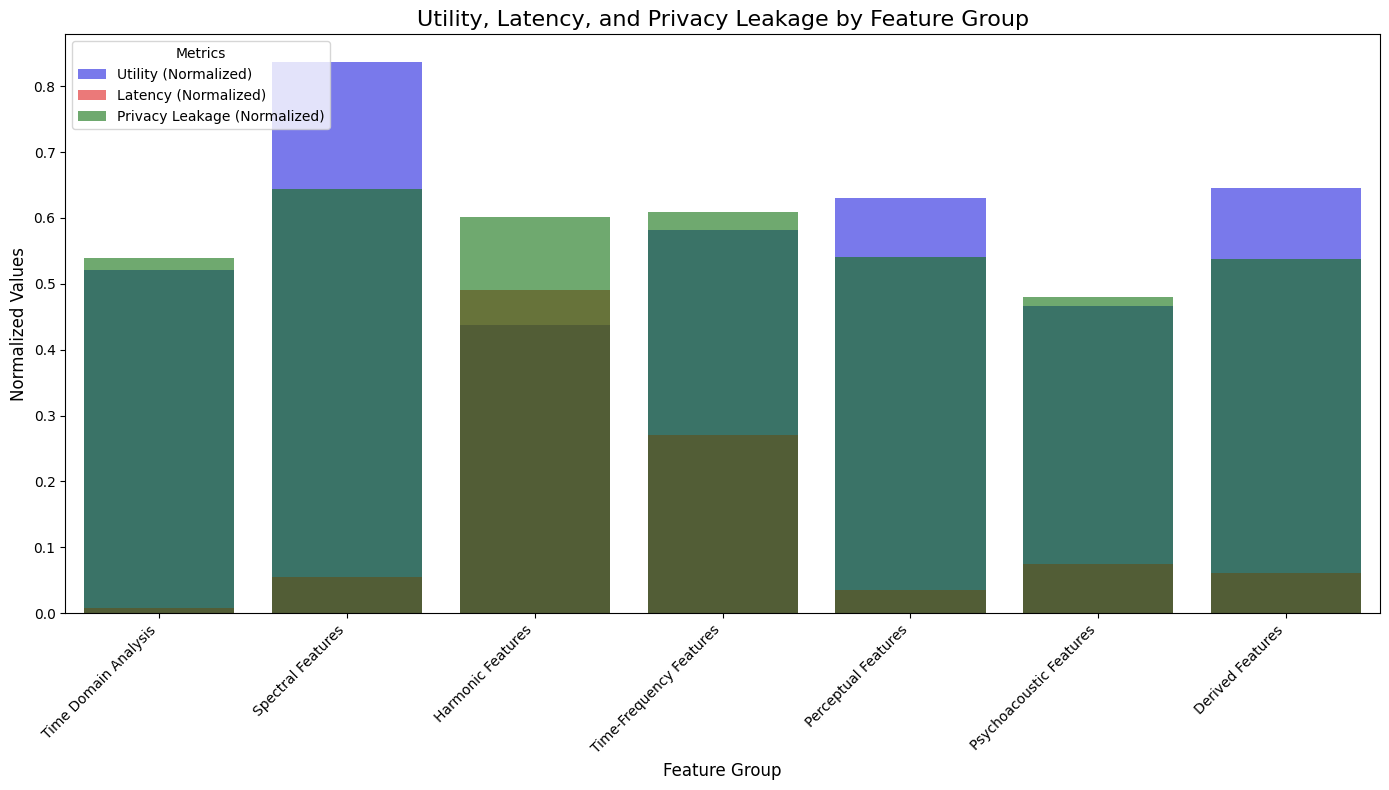

In [74]:
# Create a single plot with utility, latency, and privacy leakage for each feature group

plt.figure(figsize=(14, 8))

# Plotting utility
sns.barplot(data=grouped_df, x='Group', y='Average Utility', color='blue', alpha=0.6, label='Utility (Normalized)')

# Plotting latency
sns.barplot(data=grouped_df, x='Group', y='Time (seconds)', color='red', alpha=0.6, label='Latency (Normalized)')

# Plotting privacy leakage
sns.barplot(
    data=grouped_df,
    x='Group',
    y=grouped_df[['Age Leakage', 'Gender Leakage', 'Ethnicity Leakage']].mean(axis=1),
    color='green',
    alpha=0.6,
    label='Privacy Leakage (Normalized)'
)

# Customizing the plot
plt.title('Utility, Latency, and Privacy Leakage by Feature Group', fontsize=16)
plt.xlabel('Feature Group', fontsize=12)
plt.ylabel('Normalized Values', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metrics', fontsize=10, loc='upper left')
plt.tight_layout()
plt.show()


In [72]:
import numpy as np
merged_data[merged_data['Feature'].isin(features)].iloc[:,1:].drop('Features', axis=1).mean()

Time (seconds)       0.008199
Average Utility      0.521067
Age Leakage          0.708577
Gender Leakage       0.248249
Ethnicity Leakage    0.659061
dtype: float64

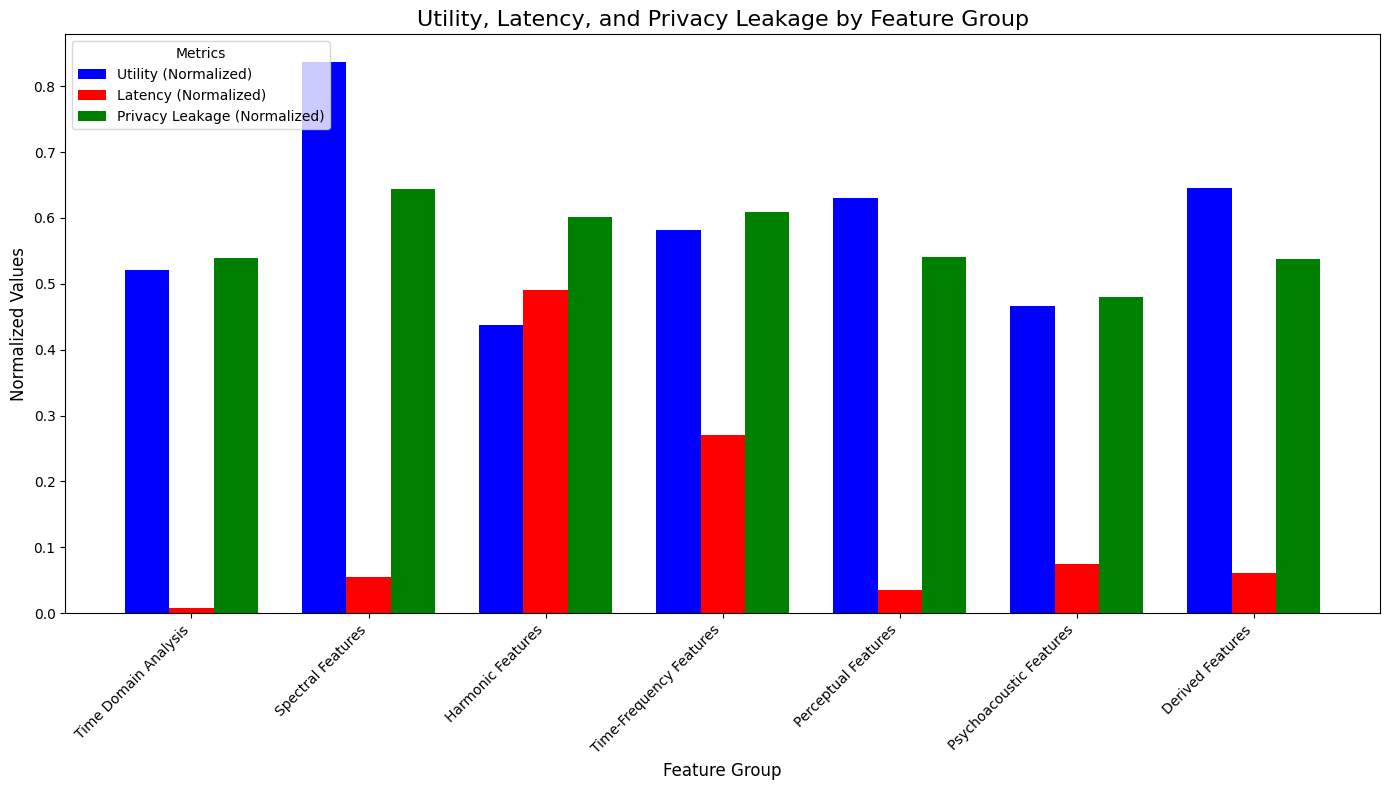

In [75]:
import numpy as np
import matplotlib.pyplot as plt

# Prepare data
x = np.arange(len(grouped_df))  # Group positions
width = 0.25  # Bar width

# Create the plot
plt.figure(figsize=(14, 8))

# Utility bars
plt.bar(x - width, grouped_df['Average Utility'], width=width, color='blue', label='Utility (Normalized)')

# Latency bars
plt.bar(x, grouped_df['Time (seconds)'], width=width, color='red', label='Latency (Normalized)')

# Privacy leakage bars
privacy_avg = grouped_df[['Age Leakage', 'Gender Leakage', 'Ethnicity Leakage']].mean(axis=1)
plt.bar(x + width, privacy_avg, width=width, color='green', label='Privacy Leakage (Normalized)')

# Customizing the plot
plt.title('Utility, Latency, and Privacy Leakage by Feature Group', fontsize=16)
plt.xlabel('Feature Group', fontsize=12)
plt.ylabel('Normalized Values', fontsize=12)
plt.xticks(x, grouped_df['Group'], rotation=45, ha='right')
plt.legend(title='Metrics', fontsize=10, loc='upper left')
plt.tight_layout()
plt.show()


In [87]:
import pandas as pd
from scipy.optimize import linprog

def optimize_features(utility_file, latency_file, privacy_file, category, latency_constraint, utility_threshold, privacy_threshold):
    """
    Select an optimal subset of features based on latency, utility, and privacy constraints for a specific application category.

    Parameters:
        utility_file (str): Path to the utility CSV file.
        latency_file (str): Path to the latency CSV file.
        privacy_file (str): Path to the privacy leakage CSV file.
        category (str): The sound category to optimize for (e.g., 'Human Sounds').
        latency_constraint (float): Maximum allowable latency in seconds.
        utility_threshold (float): Minimum utility value for a feature to be considered.
        privacy_threshold (float): Maximum allowable average privacy leakage for a feature.

    Returns:
        pd.DataFrame: DataFrame containing the selected subset of features.
    """
    # Load feature data
    feature_importance_df = pd.read_csv(utility_file)
    feature_latency_df = pd.read_csv(latency_file)
    privacy_leakage_df = pd.read_csv(privacy_file)

    # Filter utility data for the specific category
    if category not in feature_importance_df.columns:
        raise ValueError(f"Category '{category}' not found in utility file columns.")

    feature_importance_df = feature_importance_df[['Features', category]].rename(columns={category: 'Utility'})

    # Merge utility, latency, and privacy data
    merged_data = feature_latency_df.merge(
        feature_importance_df,
        left_on='Feature',
        right_on='Features',
        how='inner'
    ).merge(
        privacy_leakage_df,
        on='Feature',
        how='inner'
    )

    # Calculate average privacy leakage
    merged_data['Average Privacy Leakage'] = merged_data[['Age Leakage', 'Gender Leakage', 'Ethnicity Leakage']].mean(axis=1)

    # Filter out features that do not meet utility and privacy thresholds
    filtered_data = merged_data[
        (merged_data['Utility'] >= utility_threshold) &
        (merged_data['Average Privacy Leakage'] <= privacy_threshold)
    ]

    # Define optimization problem inputs
    latencies = filtered_data['Time (seconds)'].values
    utilities = filtered_data['Utility'].values

    # Binary decision variables for selecting features (0 or 1)
    num_features = len(latencies)

    # Objective: Maximize total utility (negative because linprog minimizes)
    c = -utilities

    # Constraints:
    # 1. Total latency <= latency_constraint
    A = [latencies]
    b = [latency_constraint]

    # Bounds: Each feature can be selected (1) or not (0)
    bounds = [(0, 1) for _ in range(num_features)]

    # Solve using linear programming
    result = linprog(c, A_ub=A, b_ub=b, bounds=bounds, method='highs')

    # Extract selected features
    selected_indices = [i for i, x in enumerate(result.x) if x > 0.5]  # Binary selection
    selected_features = filtered_data.iloc[selected_indices]

    # Return selected features
    return selected_features[['Feature', 'Time (seconds)', 'Utility', 'Average Privacy Leakage']]

# Example usage
utility_file = 'Feature_Importance_by_Sound_Categories.csv'
latency_file = 'Individual_Feature_Extraction_Time_27s.csv'
privacy_file = 'Privacy_Leakage_Data.csv'
category = 'Human Sounds'
latency_constraint = 0.8  # Total latency constraint (e.g., 0.1 seconds)
utility_threshold = 0.01  # Minimum utility value per feature
privacy_threshold = 0.07  # Maximum average privacy leakage per feature

selected_features = optimize_features(utility_file, latency_file, privacy_file, category, latency_constraint, utility_threshold, privacy_threshold)

# Save the results to a CSV file
output_path = 'Selected_Optimal_Features.csv'
selected_features.to_csv(output_path, index=False)
print(f"Selected optimal features saved to: {output_path}")


Selected optimal features saved to: Selected_Optimal_Features.csv


In [88]:
selected_features

,Feature,Time (seconds),Utility,Average Privacy Leakage
0,RMS,0.011993,0.0379,0.027328
1,ZCR,0.007545,0.0377,0.037667
2,Peak Value,0.000217,0.0598,0.046259
3,STE,0.000313,0.0244,0.030656
4,Signal Energy,0.000272,0.0321,0.030648
5,Spectral Centroid,0.023160,0.0587,0.034323
6,Spectral Rolloff,0.023543,0.0574,0.033890
7,Spectral Flatness,0.017256,0.0317,0.037828
8,Spectral Contrast,0.026812,0.0640,0.052584
9,Chroma Features,0.046643,0.0533,0.067264


In [100]:
import pandas as pd
from scipy.optimize import linprog

def optimize_features(utility_file, latency_file, privacy_file, category, latency_constraint, utility_weight, privacy_weight):
    """
    Select an optimal subset of features by optimizing utility and privacy under latency constraints for a specific application category.

    Parameters:
        utility_file (str): Path to the utility CSV file.
        latency_file (str): Path to the latency CSV file.
        privacy_file (str): Path to the privacy leakage CSV file.
        category (str): The sound category to optimize for (e.g., 'Human Sounds').
        latency_constraint (float): Maximum allowable latency in seconds.
        utility_weight (float): Weight for the utility term in the optimization objective.
        privacy_weight (float): Weight for the privacy term in the optimization objective.

    Returns:
        pd.DataFrame: DataFrame containing the selected subset of features.
    """
    # Load feature data
    feature_importance_df = pd.read_csv(utility_file)
    feature_latency_df = pd.read_csv(latency_file)
    privacy_leakage_df = pd.read_csv(privacy_file)

    # Filter utility data for the specific category
    if category not in feature_importance_df.columns:
        raise ValueError(f"Category '{category}' not found in utility file columns.")

    feature_importance_df = feature_importance_df[['Features', category]].rename(columns={category: 'Utility'})

    # Merge utility, latency, and privacy data
    merged_data = feature_latency_df.merge(
        feature_importance_df,
        left_on='Feature',
        right_on='Features',
        how='inner'
    ).merge(
        privacy_leakage_df,
        on='Feature',
        how='inner'
    )

    # Calculate average privacy leakage
    merged_data['Average Privacy Leakage'] = merged_data[['Age Leakage', 'Gender Leakage', 'Ethnicity Leakage']].mean(axis=1)

    # Define optimization problem inputs
    latencies = merged_data['Time (seconds)'].values
    utilities = merged_data['Utility'].values
    privacies = merged_data['Average Privacy Leakage'].values

    # Binary decision variables for selecting features (0 or 1)
    num_features = len(latencies)

    # Objective: Maximize utility and minimize privacy (negative because linprog minimizes)
    # Objective function: -(utility_weight * utilities - privacy_weight * privacies)
    c = -(utility_weight * utilities - privacy_weight * privacies)

    # Constraints:
    # 1. Total latency <= latency_constraint
    A = [latencies]
    b = [latency_constraint]

    # Bounds: Each feature can be selected (1) or not (0)
    bounds = [(0, 1) for _ in range(num_features)]

    # Solve using linear programming
    result = linprog(c, A_ub=A, b_ub=b, bounds=bounds, method='highs')

    # Extract selected features
    selected_indices = [i for i, x in enumerate(result.x) if x > 0.5]  # Binary selection
    selected_features = merged_data.iloc[selected_indices]

    # Return selected features
    return selected_features[['Feature', 'Time (seconds)', 'Utility', 'Average Privacy Leakage']]

# Example usage
utility_file = 'Feature_Importance_by_Sound_Categories.csv'
latency_file = 'Individual_Feature_Extraction_Time_27s.csv'
privacy_file = 'Privacy_Leakage_Data.csv'
category = 'Human Sounds'
latency_constraint = 0.4  # Total latency constraint
utility_weight = 0.5  # Weight for utility in the optimization objective
privacy_weight = 0.5  # Weight for privacy in the optimization objective

selected_features = optimize_features(utility_file, latency_file, privacy_file, category, latency_constraint, utility_weight, privacy_weight)

# Save the results to a CSV file
output_path = 'Selected_Optimal_Features.csv'
selected_features.to_csv(output_path, index=False)
print(f"Selected optimal features saved to: {output_path}")


Selected optimal features saved to: Selected_Optimal_Features.csv


In [118]:
category = 'Human Sounds'

selected_features = optimize_features(utility_file, latency_file, privacy_file, category, latency_constraint, utility_weight, privacy_weight)

selected_features

,Feature,Time (seconds),Utility,Average Privacy Leakage
0,RMS,0.011993,0.0379,0.027328
2,Peak Value,0.000217,0.0598,0.046259
4,Signal Energy,0.000272,0.0321,0.030648
5,Spectral Centroid,0.023160,0.0587,0.034323
6,Spectral Rolloff,0.023543,0.0574,0.033890
8,Spectral Contrast,0.026812,0.0640,0.052584
16,Timbre,0.055155,0.0805,0.053457
18,Jitter,0.001245,0.0427,0.034613
19,Shimmer,0.000458,0.0414,0.028285
20,Bark Coefficients,0.054107,0.0397,0.032840


In [117]:
category = 'Interior Sounds'
selected_features = optimize_features(utility_file, latency_file, privacy_file, category, latency_constraint, utility_weight, privacy_weight)


selected_features

,Feature,Time (seconds),Utility,Average Privacy Leakage
0,RMS,0.011993,0.0312,0.027328
1,ZCR,0.007545,0.0414,0.037667
2,Peak Value,0.000217,0.0472,0.046259
4,Signal Energy,0.000272,0.0315,0.030648
5,Spectral Centroid,0.023160,0.0576,0.034323
6,Spectral Rolloff,0.023543,0.0576,0.033890
7,Spectral Flatness,0.017256,0.0421,0.037828
8,Spectral Contrast,0.026812,0.0590,0.052584
15,Wavelet Features,0.306826,0.0635,0.047640
16,Timbre,0.055155,0.0677,0.053457


In [120]:
category = 'Interior Sounds'
selected_features = optimize_features(utility_file, latency_file, privacy_file, category, latency_constraint, utility_weight=0.5, privacy_weight=0.5)


selected_features

,Feature,Time (seconds),Utility,Average Privacy Leakage
0,RMS,0.011993,0.0312,0.027328
1,ZCR,0.007545,0.0414,0.037667
2,Peak Value,0.000217,0.0472,0.046259
4,Signal Energy,0.000272,0.0315,0.030648
5,Spectral Centroid,0.023160,0.0576,0.034323
6,Spectral Rolloff,0.023543,0.0576,0.033890
7,Spectral Flatness,0.017256,0.0421,0.037828
8,Spectral Contrast,0.026812,0.0590,0.052584
15,Wavelet Features,0.306826,0.0635,0.047640
16,Timbre,0.055155,0.0677,0.053457


In [2]:
import pandas as pd
from scipy.optimize import linprog

def optimize_features_with_tradeoff(utility_file, latency_file, privacy_file, category, latency_constraint, alpha):
    """
    Select an optimal subset of features by balancing utility and privacy leakage under latency constraints using a single trade-off parameter.

    Parameters:
        utility_file (str): Path to the utility CSV file.
        latency_file (str): Path to the latency CSV file.
        privacy_file (str): Path to the privacy leakage CSV file.
        category (str): The sound category to optimize for (e.g., 'Human Sounds').
        latency_constraint (float): Maximum allowable latency in seconds.
        alpha (float): Trade-off parameter (0 <= alpha <= 1) to balance utility and privacy.

    Returns:
        pd.DataFrame: DataFrame containing the selected subset of features.
    """
    # Load feature data
    feature_importance_df = pd.read_csv(utility_file)
    feature_latency_df = pd.read_csv(latency_file)
    privacy_leakage_df = pd.read_csv(privacy_file)

    # print(feature_importance_df.head(), feature_latency_df.head(), privacy_leakage_df.head())

    # Filter utility data for the specific category
    if category not in feature_importance_df.columns:
        raise ValueError(f"Category '{category}' not found in utility file columns.")

    feature_importance_df = feature_importance_df[['Features', category]].rename(columns={category: 'Utility'})

    # Merge utility, latency, and privacy data
    merged_data = feature_latency_df.merge(
        feature_importance_df,
        left_on='Feature',
        right_on='Features',
        how='inner'
    ).merge(
        privacy_leakage_df,
        on='Feature',
        how='inner'
    )

    
    # Calculate average privacy leakage
    # merged_data['Average Privacy Leakage'] = merged_data[['Age Leakage', 'Gender Leakage', 'Ethnicity Leakage']].mean(axis=1)
    merged_data['Average Privacy Leakage'] = merged_data[['Privacy']]
    merged_data['Time (seconds)'] = merged_data['Cost']

    print(merged_data)
    # Define optimization problem inputs
    latencies = merged_data['Time (seconds)'].values
    utilities = merged_data['Utility'].values
    privacies = merged_data['Average Privacy Leakage'].values

    # Binary decision variables for selecting features (0 or 1)
    num_features = len(latencies)

    # Objective: Maximize utility and minimize privacy leakage with trade-off parameter alpha
    # Objective function: -(alpha * utilities - (1 - alpha) * privacies)
    c = -(alpha * utilities - (1 - alpha) * privacies)

    # Constraints:
    # 1. Total latency <= latency_constraint
    A = [latencies]
    b = [latency_constraint]

    # Bounds: Each feature can be selected (1) or not (0)
    bounds = [(0, 1) for _ in range(num_features)]

    # Solve using linear programming
    result = linprog(c, A_ub=A, b_ub=b, bounds=bounds, method='highs')

    # Extract selected features
    selected_indices = [i for i, x in enumerate(result.x) if x > 0.5]  # Binary selection
    selected_features = merged_data.iloc[selected_indices]

    # Return selected features
    return selected_features[['Feature', 'Time (seconds)', 'Utility', 'Average Privacy Leakage']]

# Example usage
utility_file = 'Feature_Importance_by_Sound_Categories.csv'
latency_file = 'Individual_Feature_Extraction_Time_27s.csv'
privacy_file = 'Privacy_Leakage_Data.csv'
category = 'Human Sounds'
latency_constraint = 0.8  # Total latency constraint
alpha = 0.7  # Trade-off parameter (e.g., 0.7 to prioritize utility over privacy)
import time
start = time.time()
selected_features = optimize_features_with_tradeoff(utility_file, latency_file, privacy_file, category, latency_constraint, alpha=0.8)
print (time.time()-start)
# Save the results to a CSV file
output_path = 'Selected_Optimal_Features.csv'
selected_features.to_csv(output_path, index=False)
print(f"Selected optimal features saved to: {output_path}")


KeyError: "None of [Index(['Privacy'], dtype='object')] are in the [columns]"

In [171]:
selected_features

,Feature,Time (seconds),Utility,Average Privacy Leakage
0,RMS,0.011993,0.0379,0.027328
1,ZCR,0.007545,0.0377,0.037667
2,Peak Value,0.000217,0.0598,0.046259
3,STE,0.000313,0.0244,0.030656
4,Signal Energy,0.000272,0.0321,0.030648
5,Spectral Centroid,0.023160,0.0587,0.034323
6,Spectral Rolloff,0.023543,0.0574,0.033890
7,Spectral Flatness,0.017256,0.0317,0.037828
8,Spectral Contrast,0.026812,0.0640,0.052584
9,Chroma Features,0.046643,0.0533,0.067264


(                          Feature      Cost
 0              Amplitude Envelope  0.000044
 1                             RMS  0.000033
 2        Zero Crossing Rate (ZCR)  0.000034
 3         Short-Term Energy (STE)  0.000025
 4               Temporal Centroid  0.000083
 5        Envelope Modulation Rate  0.000058
 6                   Silence Ratio  0.000031
 7               Spectral Centroid  0.000395
 8               Spectral Flatness  0.000356
 9               Spectral Contrast  0.000347
 10                Spectral Spread  0.000319
 11               Spectral Entropy  0.000336
 12          Spectral Irregularity  0.000308
 13                           Mean  0.000011
 14                       Variance  0.000036
 15             Standard Deviation  0.000034
 16                       Kurtosis  0.000405
 17                       Skewness  0.000311
 18                        Entropy  0.000097
 19                      Sharpness  0.000281
 20                         Timbre  0.001140
 21       

In [3]:
# # Create updated DataFrames for Cost, Privacy, and Utility
# import pandas as pd

# # Updated Cost data
# cost_data = {
#     'Feature': [
#         'Amplitude Envelope', 'RMS', 'Zero Crossing Rate (ZCR)', 'Short-Term Energy (STE)',
#         'Temporal Centroid', 'Envelope Modulation Rate', 'Silence Ratio', 'Spectral Centroid',
#         'Spectral Flatness', 'Spectral Contrast', 'Spectral Spread', 'Spectral Entropy',
#         'Spectral Irregularity', 'Mean', 'Variance', 'Standard Deviation', 'Kurtosis', 'Skewness',
#         'Entropy', 'Sharpness', 'Timbre', 'Reverberation', 'HNR', 'Jitter', 'Shimmer',
#         'Group Delay', 'Wavelet Features', 'Temporal Spectral Slope', 'Chroma Features',
#         'Low Band Energy', 'Mid Band Energy', 'High Band Energy', 'LH1000',
#         'Transient-to-Sustained Ratio', 'Tonality Index', 'Spectral Roughness',
#         'Spectral Texture Coefficients'
#     ],
#     'Cost': [
#         4.400312900543213e-05, 3.2573938369750977e-05, 3.4049153327941895e-05, 2.5466084480285645e-05,
#         8.26120376586914e-05, 5.81592321395874e-05, 3.1381845474243164e-05, 0.00039520859718322754,
#         0.00035628676414489746, 0.0003472864627838135, 0.00031904876232147217, 0.0003364980220794678,
#         0.00030750036239624023, 1.1175870895385742e-05, 3.635883331298828e-05, 3.37064266204834e-05,
#         0.0004053562879562378, 0.000311434268951416, 9.746849536895752e-05, 0.0002808123826980591,
#         0.0011397302150726318, 0.000594601035118103, 0.0005763620138168335, 6.414949893951416e-05,
#         2.2962689399719238e-05, 6.718933582305908e-05, 0.0002883225679397583, 5.996227264404297e-05,
#         0.000659063458442688, 1.9043684005737305e-05, 1.2680888175964355e-05, 0.0004749596118927002,
#         0.00045737624168395996, 2.4646520614624023e-05, 0.0002843588590621948, 0.0003618597984313965,
#         0.00036793947219848633
#     ]
# }

# Updated Privacy data
privacy_data = {
    'Feature': [
        'Amplitude Envelope', 'RMS', 'Zero Crossing Rate (ZCR)', 'Short-Term Energy (STE)',
        'Temporal Centroid', 'Envelope Modulation rate', 'Silence Ratio', 'Spectral Centroid',
        'Spectral Flatness', 'Spectral Contrast', 'Spectral Spread', 'Spectral Entropy',
        'Spectral Irregularity', 'Chroma Features', 'Mean', 'Variance', 'Standard Deviation',
        'Kurtosis', 'Skewness', 'Entropy', 'Sharpness', 'Timbre', 'Reverberation', 'HNR',
        'Jitter', 'Shimmer', 'Group Delay', 'Wavelet Features', 'Temporal Spectral Slope',
        'Transient-to-Sustained Ratio', 'Tonality Index', 'Spectral Roughness',
        'Spectral Texture Coefficients', 'Low Band Energy', 'Mid Band Energy',
        'High Band Energy', 'LH1000'
    ],
    'Privacy': [
        0.024248216345322825, 0.013532300475038709, 0.024062918957569162, 0.019502623094343325,
        0.016430834179501242, 0.024277996265290595, 0.02026882624235387, 0.023154818203877207,
        0.019910345130495808, 0.06692775798785729, 0.029908328545234435, 0.02317641080621687,
        0.016953996857502835, 0.09680534860049213, 0.022285612283394568, 0.015800037532939744,
        0.018474532019778903, 0.040432683150909816, 0.05830720997309057, 0.01562550221182028,
        0.016459603727880967, 0.07794790256406188, 0.012000049303780614, 0.03819628370086762,
        0.017433492247143165, 0.018886144210348885, 0.019787272662001695, 0.034412915911671046,
        0.016731576439385436, 0.005345646858864055, 0.021669162464893154, 0.020806861820956486,
        0.018084080724398443, 0.03544014466658337, 0.018610641066675024, 0.02112857148709568,
        0.016973351280362186
    ]
}

# # Updated Utility data
# utility_data = {
#     'Feature': [
#         'Chroma Features', 'Spectral Contrast', 'Tonality Index', 'Envelop Modulation rate',
#         'HNR', 'Spectral Spread', 'Timbre', 'Spectral Entropy', 'Spectral Centroid', 'LH1000',
#         'Mid Band Energy', 'Kurtosis', 'Zero Crossing Rate (ZCR)', 'Low Band Energy', 'Wavelet Features',
#         'High Band Energy', 'Spectral Flatness', 'Shimmer', 'Jitter', 'Mean', 'Amplitude Envelope',
#         'Silence Ratio', 'Spectral Roughness', 'Spectral Irregularity', 'Skewness', 'Sharpness',
#         'Group Delay', 'Transient-to-Sustained Ratio', 'Spectral Texture Coefficients', 'Entropy',
#         'Variance', 'Temporal Centroid', 'Short-Term Energy (STE)', 'Standard Deviation', 'RMS',
#         'Temporal Spectral Slope', 'Reverberation'
#     ],
#     'Utility': [
#         0.048239, 0.045693, 0.045091, 0.044796, 0.041650, 0.041365, 0.040784, 0.039498, 0.037530,
#         0.036804, 0.036419, 0.035594, 0.035149, 0.033648, 0.028046, 0.026958, 0.025953, 0.024570,
#         0.024315, 0.024138, 0.021351, 0.020964, 0.020817, 0.020183, 0.019976, 0.019888, 0.018954,
#         0.017894, 0.016513, 0.015365, 0.015072, 0.015050, 0.015026, 0.014913, 0.014432, 0.012330,
#         0.005032
#     ]
# }

# # # Save data to CSV files
# # cost_df = pd.DataFrame(cost_data)
# privacy_df = pd.DataFrame(privacy_data)
# # utility_df = pd.DataFrame(utility_data)

# # cost_df.to_csv("cost.csv", index=False)
# privacy_df.to_csv("privacy.csv", index=False)
# # utility_df.to_csv("utility.csv", index=False)

# # # Check saved files
# # import os
# # os.listdir()

# Example usage
utility_file = 'category_importances.csv'
latency_file = 'cost.csv'
privacy_file = 'privacy.csv'
category = 'Human Sounds'
latency_constraint = 0.5  # Total latency constraint
alpha = 1  # Trade-off parameter (e.g., 0.7 to prioritize utility over privacy)
import time
start = time.time()
selected_features = optimize_features_with_tradeoff(utility_file, latency_file, privacy_file, "Interior/Domestic", latency_constraint, alpha)

print (time.time()-start)

# Save the results to a CSV file
output_path = 'Selected_Optimal_Features.csv'
selected_features.to_csv(output_path, index=False)
print(f"Selected optimal features saved to: {output_path}")



                          Feature      Cost                       Features  \
0              Amplitude Envelope  0.000044             Amplitude Envelope   
1                             RMS  0.000033                            RMS   
2        Zero Crossing Rate (ZCR)  0.000034       Zero Crossing Rate (ZCR)   
3         Short-Term Energy (STE)  0.000025        Short-Term Energy (STE)   
4               Temporal Centroid  0.000083              Temporal Centroid   
5                   Silence Ratio  0.000031                  Silence Ratio   
6               Spectral Centroid  0.000395              Spectral Centroid   
7               Spectral Flatness  0.000356              Spectral Flatness   
8               Spectral Contrast  0.000347              Spectral Contrast   
9                 Spectral Spread  0.000319                Spectral Spread   
10               Spectral Entropy  0.000336               Spectral Entropy   
11          Spectral Irregularity  0.000308          Spectral Ir

In [258]:
selected_features

,Feature,Time (seconds),Utility,Average Privacy Leakage
0,Amplitude Envelope,0.000044,0.020512,0.024248
1,RMS,0.000033,0.033497,0.013532
2,Zero Crossing Rate (ZCR),0.000034,0.044449,0.024063
3,Short-Term Energy (STE),0.000025,0.017000,0.019503
4,Temporal Centroid,0.000083,0.020941,0.016431
5,Silence Ratio,0.000031,0.048056,0.020269
6,Spectral Centroid,0.000395,0.027718,0.023155
7,Spectral Flatness,0.000356,0.016873,0.019910
8,Spectral Contrast,0.000347,0.017827,0.066928
9,Spectral Spread,0.000319,0.047768,0.029908


In [259]:
selected_features['Feature'].tolist()

['Amplitude Envelope',
 'RMS',
 'Zero Crossing Rate (ZCR)',
 'Short-Term Energy (STE)',
 'Temporal Centroid',
 'Silence Ratio',
 'Spectral Centroid',
 'Spectral Flatness',
 'Spectral Contrast',
 'Spectral Spread',
 'Spectral Entropy',
 'Spectral Irregularity',
 'Mean',
 'Variance',
 'Standard Deviation',
 'Kurtosis',
 'Skewness',
 'Entropy',
 'Sharpness',
 'Timbre',
 'Reverberation',
 'HNR',
 'Jitter',
 'Shimmer',
 'Group Delay',
 'Wavelet Features',
 'Temporal Spectral Slope',
 'Chroma Features',
 'Low Band Energy',
 'Mid Band Energy',
 'High Band Energy',
 'LH1000',
 'Transient-to-Sustained Ratio',
 'Tonality Index',
 'Spectral Roughness',
 'Spectral Texture Coefficients']

/var/folders/qf/r_bx8wf14lx6m_jgptyp_vmr0000gq/T/ipykernel_90491/3259465032.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="Feature", x="Privacy", data=top_privacy, ax=axes[0], palette="Greens_d")
/var/folders/qf/r_bx8wf14lx6m_jgptyp_vmr0000gq/T/ipykernel_90491/3259465032.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="Feature", x="Utility", data=top_utility, ax=axes[1], palette="Blues_d")
/var/folders/qf/r_bx8wf14lx6m_jgptyp_vmr0000gq/T/ipykernel_90491/3259465032.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="Featur

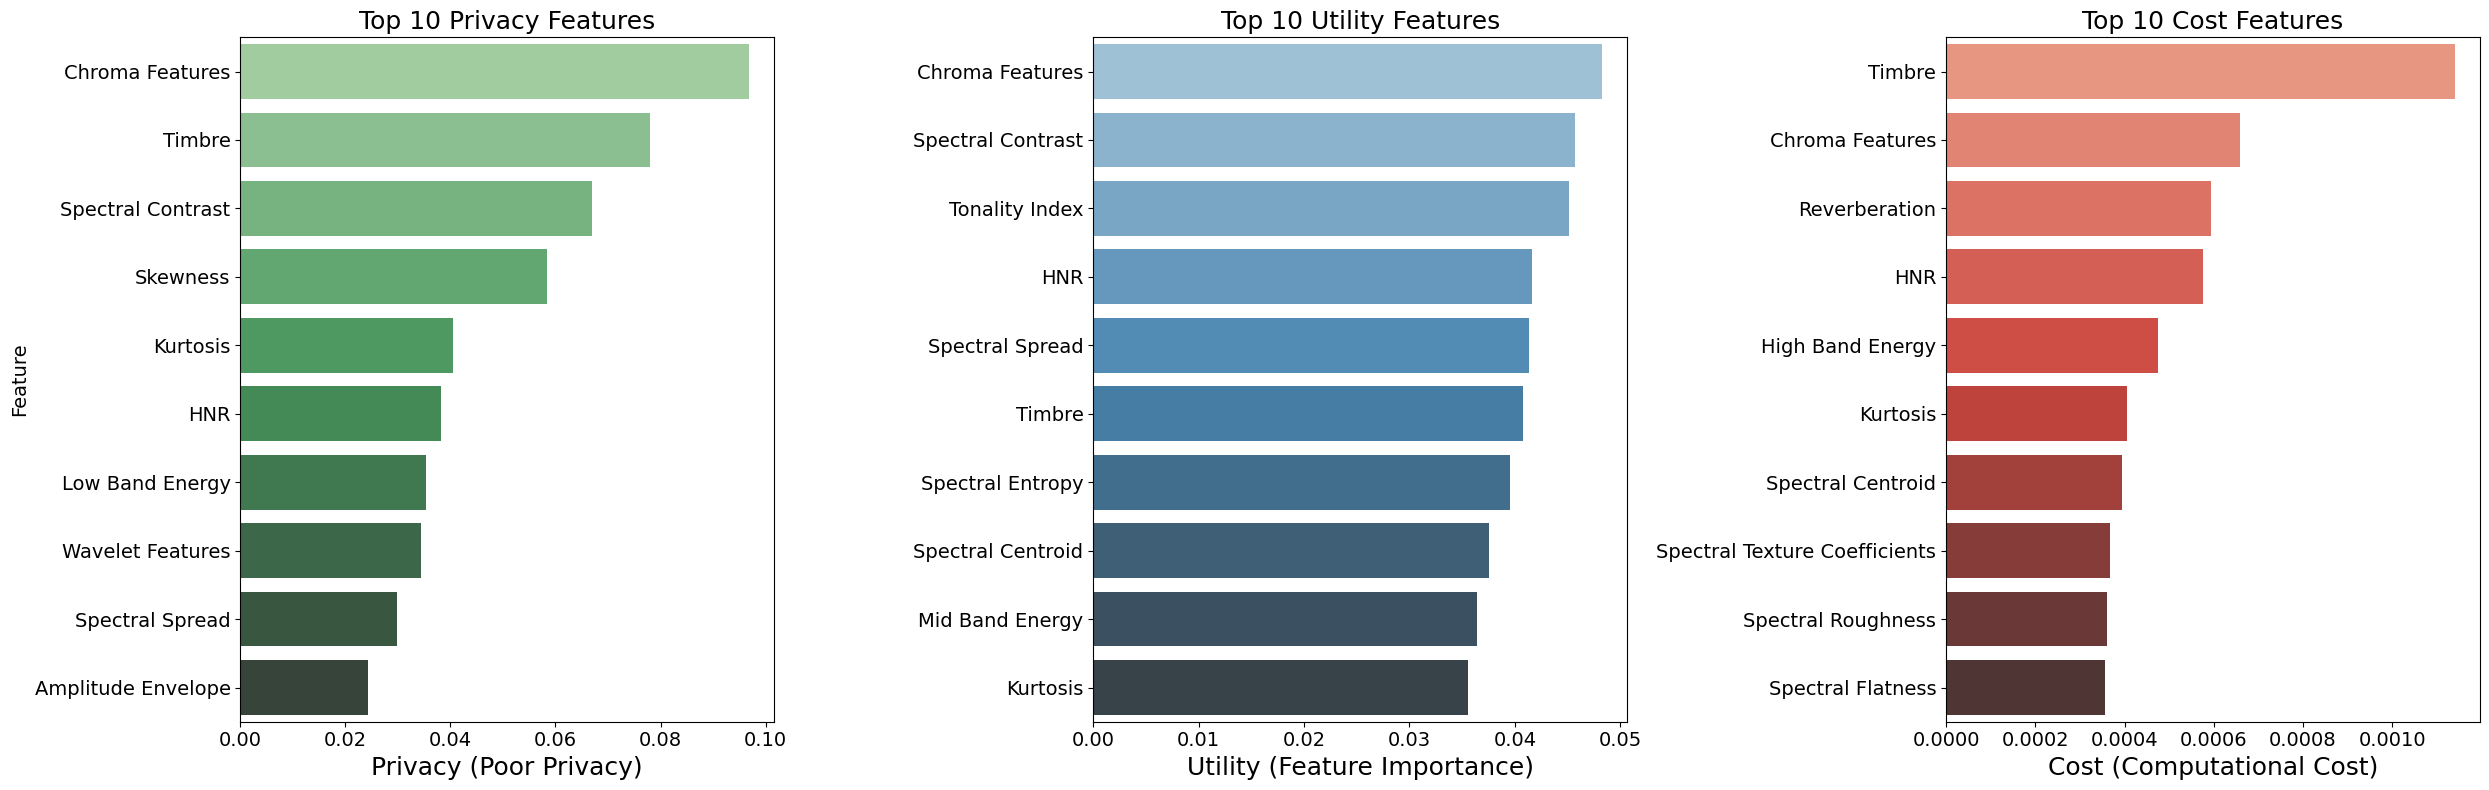

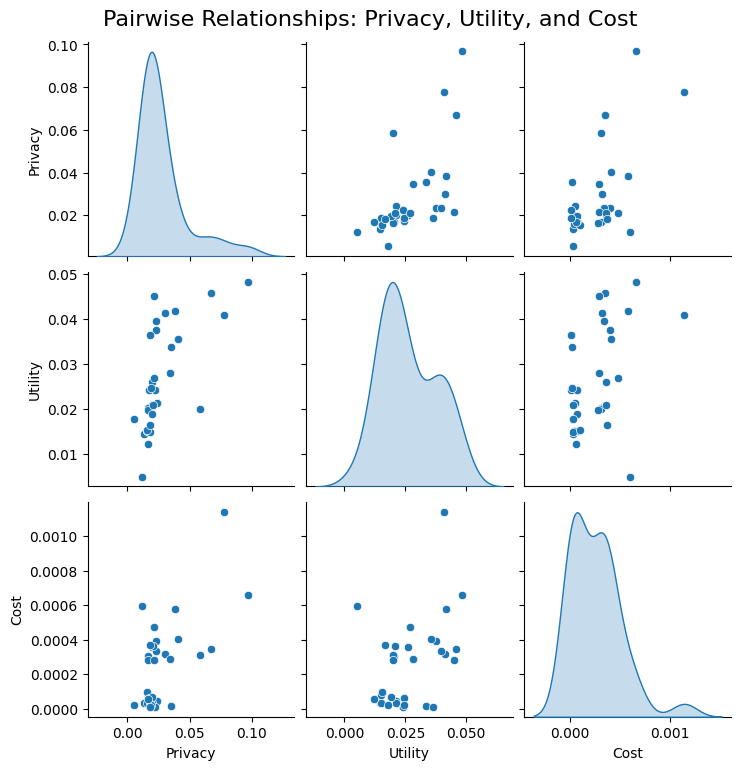

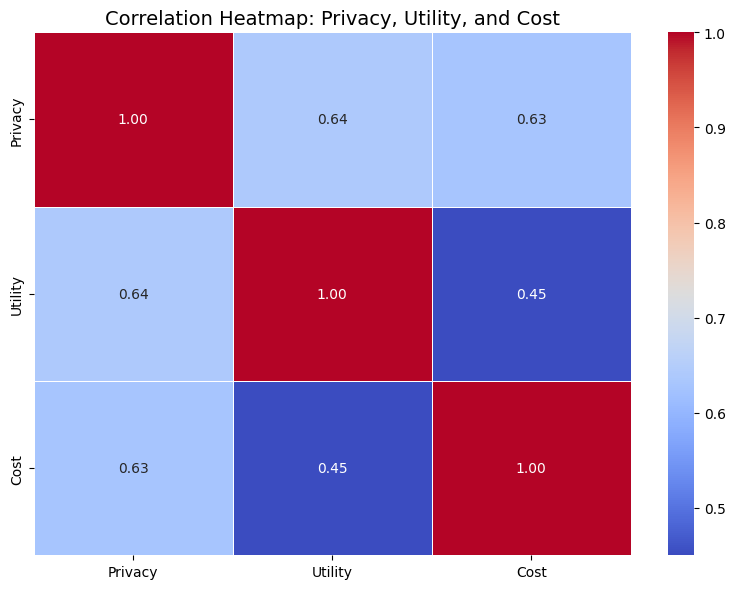

/var/folders/qf/r_bx8wf14lx6m_jgptyp_vmr0000gq/T/ipykernel_90491/3259465032.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged_df.melt(id_vars="Feature", value_vars=["Privacy", "Utility", "Cost"]),


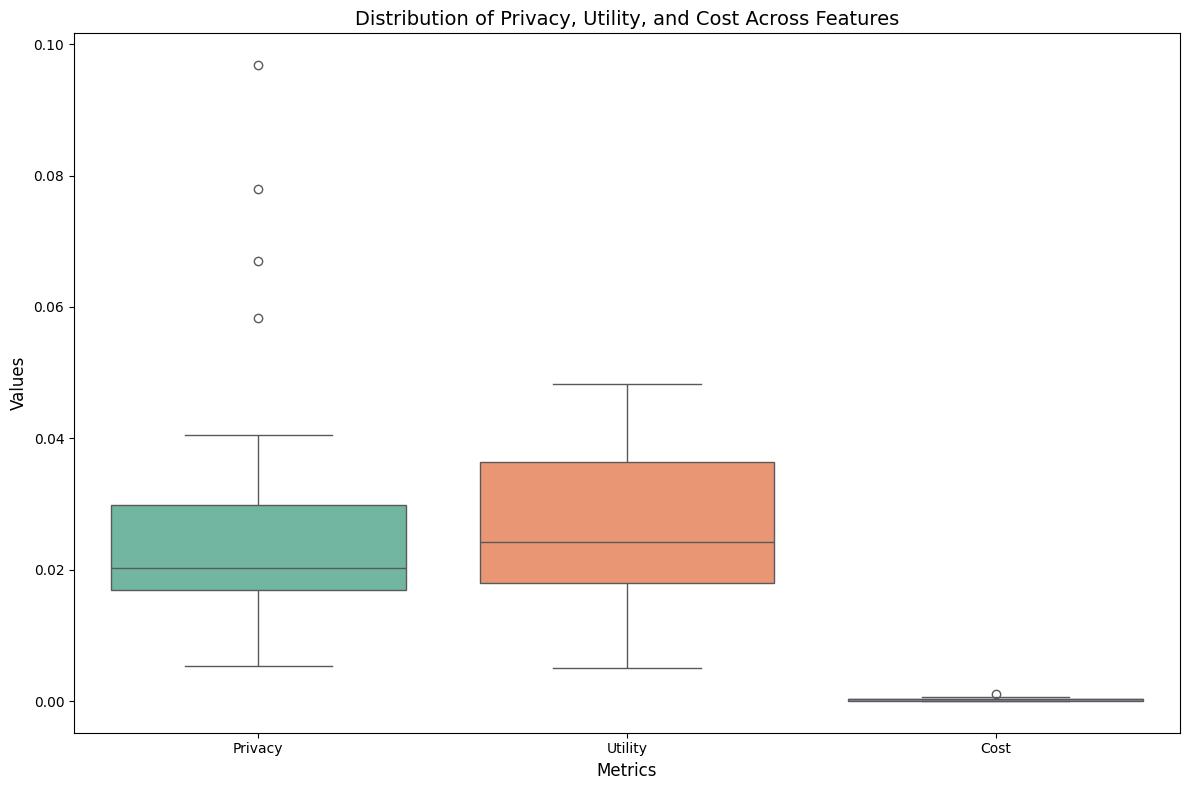

In [166]:
# Load the updated data
cost_df = pd.read_csv("cost.csv")
privacy_df = pd.read_csv("privacy.csv")
utility_df = pd.read_csv("utility.csv")

# Merge data into a single DataFrame for combined analysis
merged_df = cost_df.merge(privacy_df, on="Feature").merge(utility_df, on="Feature")

import seaborn as sns
import matplotlib.pyplot as plt

# Visualization 1: Top 10 Features by Privacy, Utility, and Cost (Side-by-Side)
top_privacy = merged_df.nlargest(10, "Privacy")
top_utility = merged_df.nlargest(10, "Utility")
top_cost = merged_df.nlargest(10, "Cost")

fig, axes = plt.subplots(1, 3, figsize=(25, 8), sharey=False)

sns.barplot(y="Feature", x="Privacy", data=top_privacy, ax=axes[0], palette="Greens_d")
axes[0].set_title("Top 10 Privacy Features", fontsize=18)
axes[0].set_xlabel("Privacy (Poor Privacy)", fontsize=18)
axes[0].set_ylabel("Feature", fontsize=14)
axes[0].tick_params(axis="both", labelsize=14)

sns.barplot(y="Feature", x="Utility", data=top_utility, ax=axes[1], palette="Blues_d")
axes[1].set_title("Top 10 Utility Features", fontsize=18)
axes[1].set_xlabel("Utility (Feature Importance)", fontsize=18)
axes[1].set_ylabel("", fontsize=14)
axes[1].tick_params(axis="both", labelsize=14)

sns.barplot(y="Feature", x="Cost", data=top_cost, ax=axes[2], palette="Reds_d")
axes[2].set_title("Top 10 Cost Features", fontsize=18)
axes[2].set_xlabel("Cost (Computational Cost)", fontsize=18)
axes[2].set_ylabel("", fontsize=14)
axes[2].tick_params(axis="both", labelsize=14)

plt.tight_layout()
plt.savefig('top10puc.png')
plt.show()

# Visualization 2: Pairwise Relationships (Privacy, Utility, and Cost)
sns.pairplot(merged_df[["Privacy", "Utility", "Cost"]], diag_kind="kde", height=2.5)
plt.suptitle("Pairwise Relationships: Privacy, Utility, and Cost", y=1.02, fontsize=16)
plt.show()

# Visualization 3: Heatmap of Correlations Between Metrics
correlation_matrix = merged_df[["Privacy", "Utility", "Cost"]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap: Privacy, Utility, and Cost", fontsize=14)
plt.tight_layout()
plt.show()

# Visualization 4: Feature-Wise Distribution of Metrics
plt.figure(figsize=(12, 8))
sns.boxplot(data=merged_df.melt(id_vars="Feature", value_vars=["Privacy", "Utility", "Cost"]),
            x="variable", y="value", palette="Set2")
plt.title("Distribution of Privacy, Utility, and Cost Across Features", fontsize=14)
plt.xlabel("Metrics", fontsize=12)
plt.ylabel("Values", fontsize=12)
plt.tight_layout()
plt.show()


/var/folders/qf/r_bx8wf14lx6m_jgptyp_vmr0000gq/T/ipykernel_90491/3723028634.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="Feature", x="Privacy", data=top_privacy, ax=axes[0], palette="Greens_d")


(array([0. , 0.2, 0.4, 0.6, 0.8, 1. ]),
 [Text(0.0, 0, '0.0'),
  Text(0.2, 0, '0.2'),
  Text(0.4, 0, '0.4'),
  Text(0.6000000000000001, 0, '0.6'),
  Text(0.8, 0, '0.8'),
  Text(1.0, 0, '1.0')])

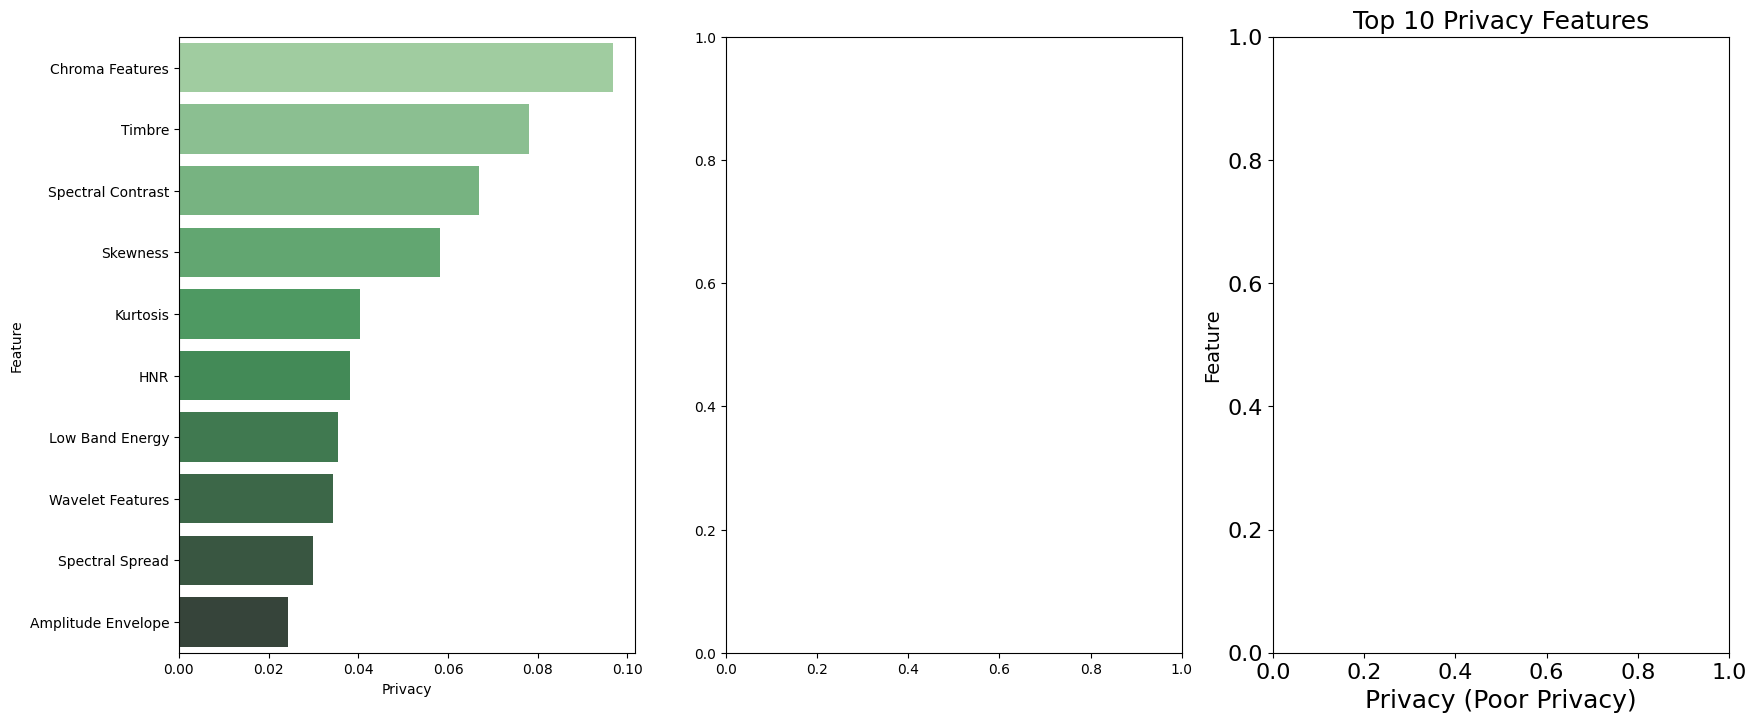

In [159]:
# Create DataFrame for category-wise feature importances
import pandas as pd

# Category-wise feature importances
category_importances = {
    'Features': [
        'Chroma Features', 'Spectral Contrast', 'Tonality Index', 'Envelop Modulation rate',
        'HNR', 'Spectral Spread', 'Timbre', 'Spectral Entropy', 'Spectral Centroid', 'LH1000',
        'Mid Band Energy', 'Kurtosis', 'Zero Crossing Rate (ZCR)', 'Low Band Energy', 'Wavelet Features',
        'High Band Energy', 'Spectral Flatness', 'Shimmer', 'Jitter', 'Mean', 'Amplitude Envelope',
        'Silence Ratio', 'Spectral Roughness', 'Spectral Irregularity', 'Skewness', 'Sharpness',
        'Group Delay', 'Transient-to-Sustained Ratio', 'Spectral Texture Coefficients', 'Entropy',
        'Variance', 'Temporal Centroid', 'Short-Term Energy (STE)', 'Standard Deviation', 'RMS',
        'Temporal Spectral Slope', 'Reverberation'],
    "Animals": [
        0.02550098, 0.01611488, 0.03789266, 0.01626182, 0.01622607,
        0.03572146, 0.0200029, 0.03282149, 0.02657111, 0.04745048,
        0.03845218, 0.04415831, 0.03511198, 0.02065204, 0.03281884,
        0.01586229, 0.01612572, 0.03058842, 0.02198136, 0.01653104,
        0.02138024, 0.03979866, 0.00626096, 0.04094566, 0.02801757,
        0.02602704, 0.02155811, 0.02909486, 0.01199126, 0.01748041,
        0.04090491, 0.02081297, 0.01716906, 0.03167695, 0.03721459,
        0.02535436, 0.03746635
    ],
    "Nature": [
        0.02209736, 0.01675313, 0.03853851, 0.01697898, 0.02038264,
        0.03541847, 0.01997029, 0.03888163, 0.02449863, 0.03930302,
        0.03977472, 0.03708556, 0.04096845, 0.02312125, 0.03033663,
        0.01700908, 0.01694088, 0.02757334, 0.02437386, 0.01701423,
        0.02191317, 0.03848981, 0.00778308, 0.03644663, 0.02502694,
        0.0255546, 0.01922689, 0.02973163, 0.01462369, 0.01804417,
        0.04065246, 0.02287451, 0.01862874, 0.03228178, 0.03411775,
        0.02787404, 0.03970944
    ],
    "Human,Non-Speech": [
        0.0238719, 0.01640805, 0.03091903, 0.01680902, 0.01792689,
        0.04553202, 0.02211185, 0.0302141, 0.02572241, 0.04122624,
        0.03920851, 0.03369112, 0.04505553, 0.02442635, 0.02367051,
        0.01638213, 0.01771028, 0.03806863, 0.0207542, 0.01903726,
        0.02238116, 0.03665522, 0.00644188, 0.04075762, 0.02808617,
        0.0235165, 0.01794095, 0.02914698, 0.01555156, 0.01600056,
        0.04741586, 0.02410897, 0.01783637, 0.03312793, 0.02906198,
        0.02984931, 0.03337495
    ],
    "Interior/Domestic": [
        0.02153416, 0.01782675, 0.03344424, 0.01704848, 0.02122547,
        0.04776779, 0.02103147, 0.03463078, 0.0277184, 0.04151137,
        0.03649655, 0.03534618, 0.04444924, 0.02112986, 0.0289218,
        0.01641405, 0.01687268, 0.03474432, 0.02052261, 0.01619453,
        0.02051204, 0.04805619, 0.0065933, 0.04201754, 0.02504333,
        0.02181544, 0.01824893, 0.02650811, 0.01416504, 0.01876419,
        0.04240749, 0.02094089, 0.01699951, 0.03261259, 0.03349682,
        0.02481758, 0.0321703
    ],
    "Exterior/Urban": [
        0.02410281, 0.01805475, 0.02916866, 0.01874146, 0.02244882,
        0.050878, 0.01979321, 0.02956738, 0.02907476, 0.03851194,
        0.03765406, 0.03514888, 0.05040917, 0.02134461, 0.02530191,
        0.01896602, 0.01941026, 0.03284008, 0.02158248, 0.01825003,
        0.02068399, 0.03665029, 0.00900626, 0.03449442, 0.02702111,
        0.02494567, 0.02195527, 0.02742261, 0.01990753, 0.01851807,
        0.03619245, 0.02159062, 0.01870373, 0.03036527, 0.0321551,
        0.02875863, 0.03037966
    ]
}

# Convert to DataFrame
categories_df = pd.DataFrame(category_importances)

# Save to CSV
categories_df.to_csv("category_importances.csv", index=False)

# Verify file creation
import os
os.listdir()


['ESC_y_long.npy',
 'output (2).png',
 'ESC_X_long.npy',
 'Individual_Feature_Extraction_Time_27s.csv',
 'all_features.npy',
 'voice.csv',
 'corr_gender.png',
 '27_feat.npy',
 'speaker_leakage_ourfeatures.png',
 'top10puc.png',
 'asr_fairness_audio',
 'ESC-50-extractedFeatures-LongFeatureList-Copy1.ipynb',
 'ESC-50_category.png',
 'Audio_Features_Block_Diagram.png',
 'l27_feat_labels.npy',
 'ESC-50-master',
 'archive (2)',
 'imwut25_audio_privacy (1).pdf',
 'long_features_labels.npy',
 'Individual_Feature_Extraction_Time_27s.numbers',
 'corrmipi_gender.png',
 'speaker-related-leakage-Copy1.ipynb',
 'archive (2).zip',
 'Bhawana_CV.pdf',
 'ESC-50-extractedFeatures-mine.ipynb',
 'Ankita.ipynb',
 'Untitled1.ipynb',
 'ESC-50-extractedFeatures-LongFeatureList.ipynb',
 'heatmap2.png',
 '27_feat_labels.npy',
 'WhatsApp Image 2024-10-24 at 12.03.08 PM.jpeg',
 'archive (3).zip',
 '.DS_Store',
 'ESC-50-mfcc-rf.ipynb',
 'test_blended_0.wav',
 'speaker-related-leakage.ipynb',
 'ESC-50-master.zip',


In [209]:
categories_df

,Features,Animals,Nature,"Human,Non-Speech",Interior/Domestic,Exterior/Urban
0,Chroma Features,0.025501,0.022097,0.023872,0.021534,0.024103
1,Spectral Contrast,0.016115,0.016753,0.016408,0.017827,0.018055
2,Tonality Index,0.037893,0.038539,0.030919,0.033444,0.029169
3,Envelop Modulation rate,0.016262,0.016979,0.016809,0.017048,0.018741
4,HNR,0.016226,0.020383,0.017927,0.021225,0.022449
5,Spectral Spread,0.035721,0.035418,0.045532,0.047768,0.050878
6,Timbre,0.020003,0.019970,0.022112,0.021031,0.019793
7,Spectral Entropy,0.032821,0.038882,0.030214,0.034631,0.029567
8,Spectral Centroid,0.026571,0.024499,0.025722,0.027718,0.029075
9,LH1000,0.047450,0.039303,0.041226,0.041511,0.038512


In [212]:
privacy_df, cost_df

(                          Feature   Privacy
 0              Amplitude Envelope  0.024248
 1                             RMS  0.013532
 2        Zero Crossing Rate (ZCR)  0.024063
 3         Short-Term Energy (STE)  0.019503
 4               Temporal Centroid  0.016431
 5        Envelope Modulation rate  0.024278
 6                   Silence Ratio  0.020269
 7               Spectral Centroid  0.023155
 8               Spectral Flatness  0.019910
 9               Spectral Contrast  0.066928
 10                Spectral Spread  0.029908
 11               Spectral Entropy  0.023176
 12          Spectral Irregularity  0.016954
 13                Chroma Features  0.096805
 14                           Mean  0.022286
 15                       Variance  0.015800
 16             Standard Deviation  0.018475
 17                       Kurtosis  0.040433
 18                       Skewness  0.058307
 19                        Entropy  0.015626
 20                      Sharpness  0.016460
 21       

In [237]:
# Load the cost data from the saved CSV file
cost_df = pd.read_csv("cost.csv")

# Lists of features for each group
alpha1_l2 = [
    'Amplitude Envelope', 'RMS', 'Zero Crossing Rate (ZCR)', 'Short-Term Energy (STE)', 'Temporal Centroid',
    'Silence Ratio', 'Spectral Centroid', 'Spectral Flatness', 'Spectral Contrast', 'Spectral Spread',
    'Spectral Entropy', 'Spectral Irregularity', 'Mean', 'Variance', 'Standard Deviation', 'Kurtosis',
    'Skewness', 'Entropy', 'Sharpness', 'Timbre', 'Reverberation', 'HNR', 'Jitter', 'Shimmer', 'Group Delay',
    'Wavelet Features', 'Temporal Spectral Slope', 'Chroma Features', 'Low Band Energy', 'Mid Band Energy',
    'High Band Energy', 'LH1000', 'Transient-to-Sustained Ratio', 'Tonality Index', 'Spectral Roughness',
    'Spectral Texture Coefficients'
]

alpha0_8_l2 = [
    'Amplitude Envelope', 'RMS', 'Zero Crossing Rate (ZCR)', 'Short-Term Energy (STE)', 'Temporal Centroid',
    'Silence Ratio', 'Spectral Centroid', 'Spectral Flatness', 'Spectral Spread', 'Spectral Entropy',
    'Spectral Irregularity', 'Mean', 'Variance', 'Standard Deviation', 'Kurtosis', 'Skewness', 'Entropy',
    'Sharpness', 'Timbre', 'Reverberation', 'HNR', 'Jitter', 'Shimmer', 'Group Delay', 'Wavelet Features',
    'Temporal Spectral Slope', 'Chroma Features', 'Low Band Energy', 'Mid Band Energy', 'High Band Energy',
    'LH1000', 'Transient-to-Sustained Ratio', 'Tonality Index', 'Spectral Roughness', 'Spectral Texture Coefficients'
]

alpha0_5_l2 = [
    'RMS', 'Zero Crossing Rate (ZCR)', 'Temporal Centroid', 'Silence Ratio', 'Spectral Centroid',
    'Spectral Spread', 'Spectral Entropy', 'Spectral Irregularity', 'Variance', 'Standard Deviation',
    'Kurtosis', 'Entropy', 'Sharpness', 'Reverberation', 'Jitter', 'Shimmer', 'Group Delay',
    'Temporal Spectral Slope', 'Mid Band Energy', 'LH1000', 'Transient-to-Sustained Ratio', 'Tonality Index'
]

alpha0_3_l2 = [
    'RMS', 'Spectral Irregularity', 'Variance', 'Reverberation', 'LH1000', 'Transient-to-Sustained Ratio'
]

# Calculate total latency for each list by summing the costs
def calculate_total_latency(feature_list, cost_data):
    # Filter the costs for the given features
    total_latency = cost_data[cost_data['Feature'].isin(feature_list)]['Cost'].sum()
    return total_latency

# Compute the total latency for each group
latency_alpha1_l2 = calculate_total_latency(alpha1_l2, cost_df)
latency_alpha0_8_l2 = calculate_total_latency(alpha0_8_l2, cost_df)
latency_alpha0_5_l2 = calculate_total_latency(alpha0_5_l2, cost_df)
latency_alpha0_3_l2 = calculate_total_latency(alpha0_3_l2, cost_df)

latency_alpha1_l2, latency_alpha0_8_l2, latency_alpha0_5_l2, latency_alpha0_3_l2


(0.008963435888289418,
 0.00861614942550562,
 0.003980502486228481,
 0.0014530569314955633)